# Dissection Trajectory Binary Mask Generator

This notebook is **stand-alone** and does not depend on the main automation pipeline files. We'll integrate this module into the pipeline later.

## Dependencies
- `opencv-python`
- `numpy`
- `matplotlib`
- `scikit-image`
- `networkx`

If needed:
```bash
pip install opencv-python numpy matplotlib scikit-image networkx
```

In [3]:
# pip install opencv-python numpy matplotlib scikit-image networkx

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.morphology import skeletonize
import networkx as nx


# ------ Configurable parameters ------

CFG = {
    "use_clahe": True,
    "tissue_v_min": 40,
    "tissue_l_min": 40,
    "cloth_h_min": 85,
    "cloth_h_max": 135,
    "cloth_s_min": 25,
    "tissue_dilate_kernel": 40,
    # marker_mode controls which colour-detection path is used:
    #   "auto"  – try color first; if weak, toggle between dark and light by pixel count
    #   "color" – always use the HSV color (purple/blue) mask  [original default behaviour]
    #   "dark"  – always use the dark (low-V, high-S) mask
    #   "light" – always use the light (high-V, low-S) mask
    "marker_mode": "auto",
    "marker_h_min": 112,
    "marker_h_max": 160,
    "marker_s_min": 90,
    "marker_v_min": 40,
    "min_color_pixels": 10000,
    # Light-marker mask: captures bright (near-white) ink on tissue.
    "light_v_min":      200,   # min HSV-V for bright marker pixels
    "light_s_max":       60,   # max HSV-S (keeps near-white; rejects coloured)
    # MV-D toggle: 4-voter majority decides dark vs light in auto mode.
    # When >= mv_votes_needed of the 4 classifiers vote "color", light mask is used;
    # otherwise dark mask is used.  Thresholds learned from 108 labeled images.
    # Set mv_votes_needed to None to disable MV-D and always fall back to dark mask.
    "mv_votes_needed":           2,
    "mv_ratio_threshold":        0.5748,  # col_px / (drk_px + 1) >= T -> color vote
    "mv_narrow_threshold":       147,     # narrow_dark_px < T -> color vote
    "mv_narrow_ratio_threshold": 2.402,   # col_px / (narrow_dark + 1) >= T -> color vote
    "mv_white_threshold":        188112,  # white_tissue_px >= T -> color vote
    "open_kernel": 2,
    "close_kernel": 11,
    "close_iters": 1,
    "min_component_area": 25,
    "max_component_area_ratio": 0.03,
    "prune_branch_length": 10,
    "line_thickness": 3,
    "max_link_dist": 165.0,
    "min_chain_nodes": 2,
    # Border exclusion: only blobs that are BOTH near the image edge AND
    # smaller than border_margin_max_area are suppressed as instrument artifacts.
    # This prevents suppressing valid ink marks that happen to be near the edge
    # (e.g. a mark at the top of the tissue) while still removing tiny noise
    # blobs from instrument hardware visible along the border.
    "border_margin_px":       30,
    "border_margin_max_area": 300,   # px; blobs larger than this are NOT border-suppressed
    # Right/bottom-edge exclusion: suppress ALL blobs within N px of that edge.
    # Default 0 = disabled.  Use per-image when instrument hardware sits at edge.
    "right_border_margin_px":  0,
    "bottom_border_margin_px": 0,
    # Tiny-blob anchor check: if a blob's area is below median × ratio AND it
    # has no blob with area >= median × anchor_large_ratio within max_link_dist,
    # suppress it as isolated noise.  Valid tiny ink dots along a trajectory
    # always have larger neighbors; isolated tiny artifacts do not.
    # Default 0.0 = disabled (per-image override).
    "tiny_blob_req_anchor_ratio":   0.0,
    "tiny_blob_anchor_large_ratio": 2.0,
    "link_thickness": 4,
    "shadow_density_radius":  250,   # radius for cluster-area and B2 density checks
    "shadow_linearity_radius": 200,  # smaller PCA neighbourhood for linearity test;
                                     # prevents far trajectory blobs creating false 2D appearance
    "shadow_density_count":   4,
    "shadow_linearity_threshold": 4.0,
    "shadow_large_ratio":      8.0,
    "shadow_solidity_min":     0.65,
    "shadow_strict_large_ratio": 6.0,
    "shadow_strict_solidity":    0.55,   # lowered from 0.60: blobs with sol=[0.55,0.60) now
                                         # skip B1 and go to B2/linearity (e.g. 60.95 blob#12
                                         # sol=0.57, 67.113 blob#2 sol=0.55)
    # B1 linearity-escape self-ratio guard: the linearity escape only applies
    # if at least one non-shadow neighbour has area >= this fraction of the
    # candidate blob's own area.  Prevents an isolated large shadow blob from
    # escaping B1 suppression just because its small/moderate neighbours happen
    # to be collinear.  Set 0.0 to disable (old behaviour).
    "b1_large_self_ratio": 0.12,        # lowered from 0.25: allows escape when largest neighbour
                                         # is ≥12% of candidate area (e.g. 11.119 blob#5 area=3015,
                                         # neighbour area=376 → 376/3015=0.125 ≥ 0.12)
    "shadow_abs_area_ratio":     0.008,  # raised from 0.0042; big valid ink blobs can exceed 0.42%
    # Cluster-area shadow: if the SUM of areas of all blobs within
    # shadow_density_radius of blob i exceeds shadow_cluster_area_ratio * total_px,
    # treat blob i as a shadow component.  Catches fragmented shadow regions
    # (many small components that each pass the per-blob threshold individually).
    "shadow_cluster_area_ratio": 0.020,  # 2 % of total image px
    "chain_max_angle_deg":    55,    # DP turn limit — keep tight to avoid noise paths in DP
    # Extension uses a wider angle so abrupt-curve endpoints can still be reached
    # after the core chain is found (e.g. 43.68 has a 62° turn at the endpoint).
    "ext_max_angle_deg":      65,
    "chain_outlier_ratio":   3.0,
    # ── FIX: floor for trim reference so short-median chains don't over-trim ──
    "trim_ref_floor_ratio":  0.30,   # floor = max_link_dist * this value (96 px)
    # Endpoint extension: after trim, greedily add non-chain keep blobs within
    # this distance that continue the trajectory direction.
    # Area filtering is deliberately omitted here — endpoint_trim (angle+size)
    # handles cleanup of any spurious small blobs added by extension.
    "chain_endpoint_ext_dist": 380,
    # Post-extension segment pruning: after extension, any chain link longer than
    # ext_seg_prune_dist (px) that has fewer than ext_seg_min_blobs blobs on the
    # SMALLER side of the split is removed.  Prevents small isolated noise clusters
    # from being attached via long extension jumps.
    "ext_seg_prune_dist":  218,  # px — long links checked for isolated segment
    "ext_seg_min_blobs":          3,    # min blobs on small side to keep it
    # Never prune a small side that contains a blob with area >= this threshold.
    # A large blob is significant ink regardless of how few neighbours it has.
    # Default 0 = disabled.
    "ext_seg_protect_large_area": 500,  # 60.105: right-end blob area=918 must survive
    # Sparkle filter: if the chain median area is below this fraction of the
    # 3rd-largest keep blob, the chain is dominated by noise dots.  Re-run DP
    # using only significant blobs to find the real ink trajectory.
    "sparkle_filter_ratio": 0.110,
    "sparkle_loop_ratio":   0.35,   # higher threshold applied when chain forms a near-loop
    # For the sparkle sig-only retry DP, allow longer links so large-blob spiral
    # trajectories (e.g. 43.186) with gaps > max_link_dist can be reconnected.
    # Sig blobs are large and unlikely to form spurious noise connections.
    "sparkle_sig_max_link_dist": 320,
    # Proportional distance limit for sparkle sig DP: max link = max_link_dist +
    # min(area_i, area_j) / dp_link_scale.  Prevents small blobs from being
    # chained across gaps that only large blobs can justify.  0 = disabled.
    "dp_link_scale": 8,
    # Extension pass 2 (loop-triggered sparkle): after all endpoint trimming,
    # re-extend using ALL keep blobs with a wider angle.  Only fires when sparkle
    # was accepted AND the chain was a near-loop (arc trajectory).
    "ext_loop_angle_deg": 90,
    # Endpoint trimming: after extension, trim endpoint blob if it makes a turn
    # larger than this angle from the trajectory direction AND is smaller than
    # the 5th-largest blob in the chain (avoids trimming legitimate large ink marks
    # at turns, while removing spurious tiny blobs added by noisy extension).
    "endpoint_trim_angle_deg": 50,
    # Trim endpoint blob if its area is less than this fraction of the adjacent
    # blob's area — catches tiny fragments attached via a large bridge blob.
    "endpoint_trim_adj_ratio": 0.04,
    # Don't apply the adj_ratio trim if ep area >= this floor (0=disabled).
    # Protects medium-sized endpoint blobs that happen to be dwarfed by a very
    # large neighbor (e.g. 68.184 left-end blob area=161 vs neighbor 4362).
    "endpoint_trim_adj_min_area": 100,
    # Also trim endpoint if area < this fraction of the chain median — catches
    # tiny DP-chain dots that aren't direct satellites of one adjacent large blob.
    "endpoint_trim_median_ratio": 0.03,
    # Trim endpoint if dist(ep,n1) > max_link_dist AND angle > trim_angle AND
    # area < this ratio × chain_median.  Bypasses the size_thresh guard so that
    # isolated outlier dots connected via a long extension jump can be removed even
    # when they are larger than the 5th-largest chain blob.
    "endpoint_trim_long_link_ratio": 1.5,
    # Extension area gate: candidate blobs must have area >= this fraction of the
    # chain median to be added as endpoint extensions.  Filters tiny noise fragments.
    "ext_min_area_ratio": 0.05,
    # Endpoint-proportional distance limit for long-range extensions: the
    # maximum extension distance is max_link_dist + ep.area / ext_ep_scale.
    # Larger endpoint blobs can bridge larger gaps; small endpoints cannot.
    # Set 0.0 to disable.
    "ext_ep_scale": 1.0,   # lowered from 6.0: small endpoints can now bridge longer gaps
                            # (e.g. 6.107 ep area=121 → max=165+121=286px; 60.95 ep area=74
                            # → max=239px; 67.3 ep area=111 → max=276px)
    # Both-small endpoint distance trim: if both the chain endpoint AND its
    # immediate neighbour have area < ep_large_area_thr, the link between them
    # must be <= ep_small_max_dist.  If not, the endpoint is trimmed.
    # Rationale: a small blob can only justify inclusion at a large distance
    # when anchored by a large neighbour.  Set ep_large_area_thr=0 to disable.
    "ep_large_area_thr":  150,   # area >= this is "large" (no dist restriction)
    "ep_small_max_dist":  130,   # max link dist when both ep and neighbour are small
    # Bridge-node pruning: after trim_outlier_links, remove interior chain nodes
    # that are too small to justify bridging a large gap.  For each interior node
    # B between neighbours A and C: if skip_dist(A,C) > bridge_min_skip_dist AND
    # B.area < bridge_min_area_ratio * skip_dist → remove B.
    # Captures tiny "stepping-stone" blobs that lie on the path by chance but
    # add no real ink evidence.  Set bridge_min_area_ratio=0.0 to disable.
    "bridge_min_area_ratio": 0.15,   # area must be >= ratio * skip_dist to bridge
    "bridge_min_skip_dist":  200.0,  # only applied when A→C skip exceeds this (px)
    # Waypoint insertion: after extension, insert keep blobs that lie between two
    # consecutive chain nodes (acts as a shortcut anchor).  Requires the blob to
    # sit within waypoint_max_lateral px of the chord AND the turn angle at the
    # waypoint to be < waypoint_max_angle_deg (prevents concave V-shapes that
    # create skeleton loops).
    "waypoint_max_lateral":    100,  # max lateral deviation from chord (px)
    "waypoint_max_angle_deg":   60,  # max turn angle at inserted waypoint (deg)
}



In [2]:
def enhance_contrast_bgr(img_bgr):
    if not CFG["use_clahe"]:
        return img_bgr
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l2, a, b]), cv2.COLOR_LAB2BGR)


def filter_components(binary_mask, min_area, max_area_ratio):
    h, w = binary_mask.shape
    max_area = int(max_area_ratio * h * w)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    cleaned = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if min_area <= area <= max_area:
            cleaned[labels == i] = 255
    return cleaned


def build_tissue_roi(lab_l, hsv_v, hsv_h, hsv_s):
    bright = (hsv_v >= CFG["tissue_v_min"]) & (lab_l >= CFG["tissue_l_min"])
    blue_cloth = (
        (hsv_h >= CFG["cloth_h_min"]) &
        (hsv_h <= CFG["cloth_h_max"]) &
        (hsv_s >= CFG["cloth_s_min"])
    )
    tissue = bright & ~blue_cloth
    tissue_u8 = tissue.astype(np.uint8) * 255
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    tissue_u8 = cv2.morphologyEx(tissue_u8, cv2.MORPH_OPEN,  k_open)
    tissue_u8 = cv2.morphologyEx(tissue_u8, cv2.MORPH_CLOSE, k_close, iterations=2)
    k = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (CFG["tissue_dilate_kernel"], CFG["tissue_dilate_kernel"]))
    tissue_u8 = cv2.morphologyEx(tissue_u8, cv2.MORPH_CLOSE, k)
    tissue_u8 = cv2.dilate(tissue_u8, k, iterations=1)
    return tissue_u8


def segment_dark_marker(img_bgr):
    img = enhance_contrast_bgr(img_bgr)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    l, h, s, v = lab[:,:,0], hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    tissue_roi = build_tissue_roi(l, v, h, s)

    mask_color = (
        (h >= CFG["marker_h_min"]) & (h <= CFG["marker_h_max"]) &
        (s >= CFG["marker_s_min"]) & (v >= CFG["marker_v_min"])
    ).astype(np.uint8) * 255
    mask_color = cv2.bitwise_and(mask_color, tissue_roi)

    mask_dark = (
        (v <= 100) & (s >= 190) & (h >= 150) & (l <= 60)
    ).astype(np.uint8) * 255
    mask_dark = cv2.bitwise_and(mask_dark, tissue_roi)

    mask_light = (
        (v >= CFG["light_v_min"]) & (s <= CFG["light_s_max"])
    ).astype(np.uint8) * 255
    mask_light = cv2.bitwise_and(mask_light, tissue_roi)

    mode = CFG.get("marker_mode", "auto")
    if mode == "color":
        mask = mask_color
    elif mode == "dark":
        mask = mask_dark
    elif mode == "light":
        mask = mask_light
    else:  # "auto": color if strong; else MV-D decides dark vs light
        n_color = int(np.count_nonzero(mask_color))
        if n_color >= CFG["min_color_pixels"]:
            mask = mask_color
        elif CFG.get("mv_votes_needed") is not None:
            # -- MV-D: 4 independent votes, majority decides dark vs light ----
            n_dark = int(np.count_nonzero(mask_dark))

            # narrow dark ink: H in [150,165], V<=80, S>=190, L<=60
            # (excludes dark red meat at H=165-180 that inflates n_dark)
            mask_narrow = (
                (v <= 80) & (s >= 190) & (h >= 150) & (h <= 165) & (l <= 60)
            ).astype(np.uint8) * 255
            n_narrow = int(np.count_nonzero(cv2.bitwise_and(mask_narrow, tissue_roi)))

            # white tissue: V>=180, S<=60 (pale fascia surface)
            mask_white = (
                (v >= CFG["light_v_min"]) & (s <= CFG["light_s_max"])
            ).astype(np.uint8) * 255
            n_white = int(np.count_nonzero(cv2.bitwise_and(mask_white, tissue_roi)))

            ratio        = n_color / (n_dark   + 1)
            narrow_ratio = n_color / (n_narrow + 1)

            votes = 0
            if ratio        >= CFG["mv_ratio_threshold"]:        votes += 1
            if n_narrow      < CFG["mv_narrow_threshold"]:       votes += 1
            if narrow_ratio >= CFG["mv_narrow_ratio_threshold"]: votes += 1
            if n_white      >= CFG["mv_white_threshold"]:        votes += 1

            mask = mask_light if votes >= CFG["mv_votes_needed"] else mask_dark
        else:
            mask = mask_dark

    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (CFG["open_kernel"],  CFG["open_kernel"]))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (CFG["close_kernel"], CFG["close_kernel"]))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=CFG["close_iters"])
    return filter_components(mask, CFG["min_component_area"], CFG["max_component_area_ratio"])


def skeleton_to_graph(skel_bool):
    G = nx.Graph()
    ys, xs = np.where(skel_bool)
    points = set(zip(ys, xs))
    nbrs = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    for y, x in points:
        G.add_node((y, x))
        for dy, dx in nbrs:
            ny, nx_ = y+dy, x+dx
            if (ny, nx_) in points:
                w = np.sqrt(2.0) if (dy != 0 and dx != 0) else 1.0
                G.add_edge((y,x),(ny,nx_), weight=w)
    return G


def prune_short_branches(G, min_len=10):
    changed = True
    while changed:
        changed = False
        deg = dict(G.degree())
        for ep in [n for n, d in deg.items() if d == 1]:
            if ep not in G:
                continue
            path, prev, cur = [ep], None, ep
            while True:
                nbrs = [n for n in G.neighbors(cur) if n != prev]
                if not nbrs:
                    break
                nxt = nbrs[0]
                path.append(nxt)
                prev, cur = cur, nxt
                if G.degree(cur) != 2:
                    break
            if len(path) <= min_len and G.degree(path[-1]) >= 3:
                for node in path[:-1]:
                    if node in G:
                        G.remove_node(node)
                changed = True
                break
    return G


def _extract_longest_path_from_graph(skel_bool):
    h, w = skel_bool.shape
    G = skeleton_to_graph(skel_bool)
    if G.number_of_nodes() == 0:
        return np.zeros((h, w), dtype=np.uint8)
    G = prune_short_branches(G, min_len=CFG["prune_branch_length"])
    if G.number_of_nodes() == 0:
        return np.zeros((h, w), dtype=np.uint8)
    largest_cc = max(nx.connected_components(G), key=len)
    H = G.subgraph(largest_cc).copy()
    deg = dict(H.degree())
    endpoints = [n for n, d in deg.items() if d == 1]
    if len(endpoints) >= 2:
        best_path, best_dist = None, -1.0
        for i in range(len(endpoints)):
            dists, paths = nx.single_source_dijkstra(H, source=endpoints[i], weight="weight")
            for j in range(i+1, len(endpoints)):
                t = endpoints[j]
                if t in dists and dists[t] > best_dist:
                    best_dist, best_path = dists[t], paths[t]
    else:
        seed = next(iter(H.nodes()))
        d1, _ = nx.single_source_dijkstra(H, source=seed, weight="weight")
        u = max(d1, key=d1.get)
        d2, p2 = nx.single_source_dijkstra(H, source=u, weight="weight")
        best_path = p2[max(d2, key=d2.get)]
    out = np.zeros((h, w), dtype=np.uint8)
    if best_path is None or len(best_path) < 2:
        return out
    for (y1,x1),(y2,x2) in zip(best_path[:-1], best_path[1:]):
        cv2.line(out, (x1,y1), (x2,y2), 255, thickness=CFG["line_thickness"])
    return out


def _extract_component_anchors_with_features(binary_mask):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    anchors = []
    for lid in range(1, num_labels):
        area = stats[lid, cv2.CC_STAT_AREA]
        if area < CFG["min_component_area"]:
            continue
        cx, cy = centroids[lid]
        ys, xs = np.where(labels == lid)
        if len(xs) == 0:
            continue
        d2 = (xs - cx)**2 + (ys - cy)**2
        k = int(np.argmin(d2))
        ax, ay = float(xs[k]), float(ys[k])
        comp_u8 = (labels == lid).astype(np.uint8)
        M = cv2.moments(comp_u8)
        if M["m00"] > 0:
            a_m, b_m, c_m = M["mu20"]/M["m00"], M["mu11"]/M["m00"], M["mu02"]/M["m00"]
            disc = np.sqrt(max(((a_m-c_m)/2)**2 + b_m**2, 0))
            eig1 = (a_m+c_m)/2 + disc
            eig2 = (a_m+c_m)/2 - disc
            elongation = float(np.sqrt(eig1 / max(eig2, 1e-4)))
        else:
            elongation = 1.0
        contours_c, _ = cv2.findContours(comp_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours_c:
            hull_area = float(cv2.contourArea(cv2.convexHull(contours_c[0])))
            solidity = float(area) / hull_area if hull_area > 0 else 1.0
        else:
            solidity = 1.0
        anchors.append({
            "label":     lid,
            "point":     np.array([ax, ay], dtype=np.float32),
            "area":      int(area),
            "elongation": elongation,
            "solidity":  solidity,
        })
    return anchors, labels


def _suppress_shadow_components(anchors, total_px=None, img_shape=None, debug_label=""):
    if len(anchors) <= 1:
        return anchors
    pts        = np.array([a["point"]              for a in anchors], dtype=np.float32)
    areas      = np.array([a["area"]               for a in anchors], dtype=np.float32)
    solidities = np.array([a.get("solidity", 1.0)  for a in anchors], dtype=np.float32)
    N          = len(pts)
    is_shadow  = np.zeros(N, dtype=bool)
    shadow_reason = [""] * N
    area_median  = float(np.median(areas))
    large_thresh = area_median * CFG["shadow_large_ratio"]

    border_margin    = CFG.get("border_margin_px", 0)
    border_max_area  = CFG.get("border_margin_max_area", 1e9)  # only suppress small border blobs
    cluster_area_thr = (total_px * CFG.get("shadow_cluster_area_ratio", 0.0)
                        if total_px is not None else 0.0)

    for i in range(N):
        # Border exclusion: ONLY for small blobs (instrument edge noise).
        # Valid ink marks near the image boundary are larger and must not be suppressed.
        if img_shape is not None and border_margin > 0 and areas[i] <= border_max_area:
            ih, iw = img_shape
            px, py = float(pts[i][0]), float(pts[i][1])
            if min(px, iw - px, py, ih - py) < border_margin:
                is_shadow[i] = True; shadow_reason[i] = "border"; continue

        # Right-edge exclusion: suppresses any blob (any size) whose centroid is
        # within right_border_margin_px of the right image edge.  Used for
        # images where the surgical instrument sits at the far right.
        right_margin = CFG.get("right_border_margin_px", 0)
        if img_shape is not None and right_margin > 0:
            ih, iw = img_shape
            px = float(pts[i][0])
            if iw - px < right_margin:
                is_shadow[i] = True; shadow_reason[i] = "right-border"; continue

            # Bottom-edge exclusion: suppresses any blob (any size) whose centroid is
            # within bottom_border_margin_px of the bottom image edge.  Used for
            # images where instrument artifacts pull the chain downward.
            bottom_margin = CFG.get("bottom_border_margin_px", 0)
            if img_shape is not None and bottom_margin > 0:
                ih, iw = img_shape
                py = float(pts[i][1])
                if ih - py < bottom_margin:
                    is_shadow[i] = True; shadow_reason[i] = "bottom-border"; continue

        # Tiny-blob anchor check: a tiny blob with no large neighbor is isolated
        # noise.  Valid tiny ink dots along a trajectory always sit near larger
        # blobs; instrument artifacts or sparkle far from the main path do not.
        tiny_req = CFG.get("tiny_blob_req_anchor_ratio", 0.0)
        if tiny_req > 0.0 and areas[i] < area_median * tiny_req:
            large_thr = area_median * CFG.get("tiny_blob_anchor_large_ratio", 2.0)
            dists_ta  = np.linalg.norm(pts - pts[i], axis=1)
            has_anchor = np.any(
                (dists_ta < CFG["max_link_dist"]) &
                (areas    >= large_thr) &
                (np.arange(N) != i)
            )
            if not has_anchor:
                is_shadow[i] = True; shadow_reason[i] = "tiny-no-anchor"; continue

        # Type B0: per-blob absolute area
        if total_px is not None and areas[i] > total_px * CFG["shadow_abs_area_ratio"]:
            is_shadow[i] = True; shadow_reason[i] = "B0-abs"; continue

        # Cluster-area check: if the total area of all nearby blobs collectively
        # exceeds shadow_cluster_area_ratio * total_px, treat as shadow.
        # Catches fragmented shadow regions whose individual components are each
        # below the per-blob B0 threshold but form a large spatial cluster.
        if cluster_area_thr > 0:
            dists_cl = np.linalg.norm(pts - pts[i], axis=1)
            cluster_mask = dists_cl < CFG["shadow_density_radius"]
            if cluster_mask.sum() >= CFG["shadow_density_count"]:
                cluster_total = float(np.sum(areas[cluster_mask]))
                if cluster_total > cluster_area_thr:
                    is_shadow[i] = True; shadow_reason[i] = "cluster-area"; continue

        # Type B1: very large + very irregular
        if areas[i] > area_median * CFG["shadow_strict_large_ratio"] and solidities[i] < CFG["shadow_strict_solidity"]:
            # Linearity escape: if the neighbourhood within density_radius is linear,
            # this large blob sits on a real ink trajectory — skip B1 suppression.
            dists_b1   = np.linalg.norm(pts - pts[i], axis=1)
            nearby_b1  = np.where(
                (dists_b1 < CFG["shadow_density_radius"]) &
                (np.arange(N) != i) &
                (areas >= area_median * 0.25)
            )[0]
            if len(nearby_b1) >= 2:
                g_pts  = pts[np.append(nearby_b1, i)]
                c      = g_pts - g_pts.mean(axis=0)
                vals_b1 = np.sort(np.linalg.eigvalsh(c.T @ c))[::-1]
                lin_b1  = vals_b1[0] / (vals_b1[1] + 1e-6)
                b1_lin_thr = CFG.get("shadow_b1_linearity_threshold",
                                     CFG["shadow_linearity_threshold"])
                if lin_b1 >= b1_lin_thr:
                    # Extra guard: at least one non-shadow neighbour must have
                    # area >= b1_large_self_ratio × this blob's own area.
                    # Real ink large blobs travel with other large blobs; a
                    # large shadow blob whose non-shadow neighbours are all much
                    # smaller is still suppressed despite the linearity escape.
                    # Shadow blobs already marked in this pass are excluded so
                    # that a large shadow blob cannot vouch for another.
                    self_ratio = CFG.get("b1_large_self_ratio", 0.0)
                    if self_ratio > 0:
                        nearby_ns = [j for j in nearby_b1 if not is_shadow[j]]
                        if not any(areas[j] >= self_ratio * areas[i]
                                   for j in nearby_ns):
                            is_shadow[i] = True; shadow_reason[i] = "B1"; continue
                    pass  # linear AND large-neighbour condition met → real ink
                else:
                    is_shadow[i] = True; shadow_reason[i] = "B1"; continue
            else:
                is_shadow[i] = True; shadow_reason[i] = "B1"; continue
        # Type B2: large + moderately irregular + many tiny neighbours
        # Extra check: if those tiny neighbours are themselves linearly arranged,
        # the big blob is likely a real ink mark sitting along a trajectory
        # (not a shadow mass), so skip B2 suppression in that case.
        if areas[i] > large_thresh and solidities[i] < CFG["shadow_solidity_min"]:
            dists_i  = np.linalg.norm(pts - pts[i], axis=1)
            tiny_mask = (
                (dists_i < CFG["shadow_density_radius"]) &
                (areas < area_median) &
                (np.arange(N) != i)
            )
            n_tiny = int(np.sum(tiny_mask))
            if n_tiny >= CFG["shadow_density_count"] - 1:
                # Check linearity of the tiny-neighbour distribution.
                # Shadow clusters are 2D; trajectory neighbours are roughly 1D.
                tiny_pts = pts[tiny_mask]
                if len(tiny_pts) >= 3:
                    centered_t = tiny_pts - tiny_pts.mean(axis=0)
                    cov_t = centered_t.T @ centered_t
                    vals_t = np.sort(np.linalg.eigvalsh(cov_t))[::-1]
                    lin_tiny = vals_t[0] / (vals_t[1] + 1e-6)
                    if lin_tiny >= CFG["shadow_linearity_threshold"]:
                        pass  # linear tiny neighbours → real ink, fall through
                    else:
                        is_shadow[i] = True; shadow_reason[i] = "B2"; continue
                else:
                    is_shadow[i] = True; shadow_reason[i] = "B2"; continue
        # Linearity test (Type A)
        # Filter neighbourhood to significant blobs only (area >= area_median * 0.25).
        # Tiny noise dots near a trajectory bend drag the PCA cluster toward 2-D,
        # which would wrongly suppress a valid ink blob sitting at that bend.
        # Use shadow_linearity_radius (smaller than shadow_density_radius) so that
        # distant large blobs on a curve don't falsely appear as a 2D cluster.
        lin_area_thresh = area_median * 0.25
        lin_radius = CFG.get("shadow_linearity_radius", CFG["shadow_density_radius"])
        dists      = np.linalg.norm(pts - pts[i], axis=1)
        nearby_idx = np.where(
            (dists < lin_radius) &
            (np.arange(N) != i) &
            (areas >= lin_area_thresh)
        )[0]
        if len(nearby_idx) < CFG["shadow_density_count"] - 1:
            continue
        group_pts = pts[np.append(nearby_idx, i)]
        centered  = group_pts - group_pts.mean(axis=0)
        cov       = centered.T @ centered
        vals      = np.sort(np.linalg.eigvalsh(cov))[::-1]
        linearity = vals[0] / (vals[1] + 1e-6)
        if linearity < CFG["shadow_linearity_threshold"]:
            is_shadow[i] = True; shadow_reason[i] = f"linearity={linearity:.1f}"

    # ── Pass 2: re-test linearity-suppressed blobs ───────────────────────────
    # A blob may be falsely suppressed in pass 1 because a large shadow blob
    # was in its neighbourhood making it look 2D.  After pass 1, that shadow
    # is gone; re-run the linearity test excluding now-suppressed neighbours.
    # Applied to ALL sizes (not just small), since large legitimate ink marks
    # at trajectory bends can also fail the linearity test.
    for i in range(N):
        if not is_shadow[i]:
            continue
        if "linearity" not in shadow_reason[i]:
            continue
        lin_area_thresh = area_median * 0.25
        lin_radius = CFG.get("shadow_linearity_radius", CFG["shadow_density_radius"])
        dists = np.linalg.norm(pts - pts[i], axis=1)
        # Only un-suppress if a large non-suppressed "anchor" blob is nearby.
        # This prevents floating shadow clusters (far from any real trajectory blob)
        # from being incorrectly freed in images like 8.47 and 7.56.
        anchor_thresh = area_median * 2.0
        anchor_mask = (~is_shadow) & (areas >= anchor_thresh) & (np.arange(N) != i)
        if not np.any((dists < CFG["max_link_dist"]) & anchor_mask):
            continue  # no large keep blob nearby → leave as shadow
        # Very large solid blobs (> 2× large_thresh) with a nearby anchor are almost
        # certainly real ink whose neighbourhood happens to look 2-D (e.g. one off-
        # trajectory fragment skews the PCA).  Un-suppress without re-running PCA.
        if areas[i] > large_thresh * 2 and solidities[i] >= CFG["shadow_solidity_min"]:
            is_shadow[i] = False
            shadow_reason[i] = ""
            continue
        nearby_idx = np.where(
            (dists < lin_radius) &
            (~is_shadow) &                           # exclude pass-1 shadows
            (np.arange(N) != i) &
            (areas >= lin_area_thresh)
        )[0]
        if len(nearby_idx) < CFG["shadow_density_count"] - 1:
            # Large irregular blobs stay shadow even with few remaining neighbours —
            # their shadow cluster was just removed in pass 1, leaving them sparse.
            # Valid ink blobs at bends are compact; these are not.
            if areas[i] > large_thresh and solidities[i] < CFG["shadow_solidity_min"]:
                continue  # keep as shadow
            # Too few non-shadow neighbours → un-suppress
            is_shadow[i] = False
            shadow_reason[i] = ""
            continue
        group_pts = pts[np.append(nearby_idx, i)]
        centered  = group_pts - group_pts.mean(axis=0)
        cov       = centered.T @ centered
        vals      = np.sort(np.linalg.eigvalsh(cov))[::-1]
        linearity = vals[0] / (vals[1] + 1e-6)
        if linearity >= CFG["shadow_linearity_threshold"] * 0.875:
            is_shadow[i] = False
            shadow_reason[i] = ""
    # ─────────────────────────────────────────────────────────────────────────

    if debug_label:
        print(f"  [{debug_label}] shadow suppression (median_area={area_median:.0f}, "
              f"cluster_thr={cluster_area_thr:.0f} px):")
        for i, a in enumerate(anchors):
            tag = f"SHADOW({shadow_reason[i]})" if is_shadow[i] else "keep"
            print(f"    blob#{i:2d}  area={a['area']:5d}  sol={a.get('solidity',1):.2f}  "
                  f"pt=({a['point'][0]:.0f},{a['point'][1]:.0f})  {tag}")

    return [a for i, a in enumerate(anchors) if not is_shadow[i]]


def _trim_outlier_links(chain, outlier_ratio):
    """
    Remove endpoint blobs whose connecting link is an outlier vs. the reference distance.

    FIX: Reference median is computed only from links where BOTH endpoints have area >=
    25% of the 5th-largest blob in the chain (filters tiny noise blobs that create
    artifically short median distances).  Also applies a floor of
    max_link_dist * trim_ref_floor_ratio so a short-median chain never over-trims.
    """
    if len(chain) < 3:
        return chain

    pts   = np.array([c["point"] for c in chain], dtype=np.float64)
    areas = np.array([c["area"]  for c in chain], dtype=np.float64)

    while len(chain) >= 3:
        dists = np.linalg.norm(pts[1:] - pts[:-1], axis=1)

        # ── FIX: significant-blob reference ──────────────────────────────────
        sorted_areas = np.sort(areas)[::-1]
        ref_area     = sorted_areas[min(4, len(sorted_areas) - 1)]   # 5th largest
        sig_thresh   = ref_area * 0.25                                # 25 % of 5th-largest
        sig_mask     = (areas[:-1] >= sig_thresh) & (areas[1:] >= sig_thresh)
        ref_dists    = dists[sig_mask] if sig_mask.sum() >= 2 else dists
        med          = float(np.percentile(ref_dists, 75))           # P75 of sig links

        # Floor: never trim something that is merely moderately longer than
        # the typical link when all links happen to be short.
        floor = CFG["max_link_dist"] * CFG["trim_ref_floor_ratio"]
        med   = max(med, floor)
        # ─────────────────────────────────────────────────────────────────────

        bad = np.where(dists > outlier_ratio * med)[0]
        if len(bad) == 0:
            break
        split  = int(bad[0]) + 1
        piece1, piece2 = chain[:split], chain[split:]
        chain  = piece1 if len(piece1) >= len(piece2) else piece2
        pts    = np.array([c["point"] for c in chain], dtype=np.float64)
        areas  = np.array([c["area"]  for c in chain], dtype=np.float64)
    return chain


def _direction_constrained_chain(anchors, max_link_dist, max_angle_deg, dp_link_scale=0):
    """
    Longest chain with direction-continuity constraint.

    FIX: Per-node area contribution is capped at NODE_BONUS (the median area).
    This prevents a single large/shadow blob from outscoring a longer correct path
    through multiple smaller ink blobs.  Two small blobs always beat one large blob.
    """
    if len(anchors) < 2:
        return anchors

    pts        = np.array([a["point"] for a in anchors], dtype=np.float64)
    areas_arr  = np.array([a["area"]  for a in anchors], dtype=np.float64)
    N          = len(pts)
    cos_thresh = np.cos(np.radians(max_angle_deg))

    vec      = pts[None,:,:] - pts[:,None,:]
    dist_mat = np.linalg.norm(vec, axis=2)
    with np.errstate(invalid='ignore', divide='ignore'):
        uv = vec / (dist_mat[:,:,None] + 1e-8)

    if dp_link_scale > 0:
        # Proportional distance limit: allowed link distance grows with the
        # smaller of the two blob areas.  Prevents small blobs from being
        # chained over large gaps that only large blobs can legitimately span.
        min_areas      = np.minimum(areas_arr[:, None], areas_arr[None, :])
        effective_max  = max_link_dist + min_areas / dp_link_scale
        link_ok = (dist_mat > 1) & (dist_mat <= effective_max)
    else:
        link_ok = (dist_mat > 1) & (dist_mat <= max_link_dist)

    # Area-dominated scoring: blob area is the primary score driver so that
    # a chain of 3 big ink blobs beats a chain of 20 tiny sparkle dots.
    # NODE_BONUS is a tiny tie-breaker (0.1*median) so longer chains still beat
    # shorter chains when blob sizes are equal, without letting count dominate.
    # No upper cap on area — big legitimate ink blobs should be fully rewarded.
    NODE_BONUS   = float(np.median(areas_arr)) * 0.1
    capped_areas = areas_arr  # no cap: large ink blobs score proportionally

    dp   = np.where(link_ok.T, dist_mat.T * 0.001 + NODE_BONUS + capped_areas[:, np.newaxis], -1.0)
    back = np.full((N, N), -1, dtype=np.int32)

    for _ in range(N - 2):
        improved = False
        new_dp   = dp.copy()
        new_back = back.copy()
        for j in range(N):
            for i in range(N):
                if dp[i, j] < 0:
                    continue
                dir_in = uv[j, i]
                dots   = uv[i] @ dir_in
                ok     = link_ok[i] & (dots >= cos_thresh)
                ok[i]  = ok[j] = False
                cands  = dp[i, j] + dist_mat[i] * 0.001 + NODE_BONUS + capped_areas
                better = ok & (cands > new_dp[:, i])
                new_dp[:,   i] = np.where(better, cands,  new_dp[:,   i])
                new_back[:, i] = np.where(better, j,      new_back[:, i])
                improved |= bool(np.any(better))
        dp, back = new_dp, new_back
        if not improved:
            break

    if dp.max() < 0:
        return []

    end_i, end_j = map(int, np.unravel_index(np.argmax(dp), dp.shape))
    path = [end_i, end_j]
    ci, cj = end_i, end_j
    while back[ci, cj] >= 0:
        pk = int(back[ci, cj])
        path.append(pk)
        ci, cj = cj, pk
    path.reverse()
    seen, unique = set(), []
    for idx in path:
        if idx not in seen:
            seen.add(idx)
            unique.append(idx)
    if len(unique) < CFG["min_chain_nodes"]:
        return []
    return [anchors[i] for i in unique]


def _extend_endpoints(chain, keep_anchors, max_dist, max_angle_deg, dp_link_scale=0):
    """
    Greedily extend each endpoint of the chain after trimming.
    Adds non-chain keep blobs within max_dist that continue the trajectory
    direction (angle ≤ ext_max_angle_deg), preferring larger blobs.

    dp_link_scale: when > 0, apply proportional distance limit using the smaller
    of the two blobs' areas (mirrors chain DP building constraint).  Only pass
    this after sparkle retry to avoid constraining normal long-gap extensions.
    """
    if len(chain) < 2:
        return chain
    chain_labels = {c["label"] for c in chain}
    ext_angle  = max_angle_deg   # caller controls the angle limit
    cos_thresh = np.cos(np.radians(ext_angle))
    chain_med  = float(np.median([c["area"] for c in chain]))
    min_area   = chain_med * CFG.get("ext_min_area_ratio", 0.0)

    changed = True
    while changed:
        changed  = False
        available = [a for a in keep_anchors
                     if a["label"] not in chain_labels and a["area"] >= min_area]
        if not available:
            break

        # Try head then tail; restart outer loop after each successful extension
        for is_head in (True, False):
            endpoint = chain[0]  if is_head else chain[-1]
            ref_blob = chain[1]  if is_head else chain[-2]
            dir_vec  = endpoint["point"] - ref_blob["point"]
            norm     = float(np.linalg.norm(dir_vec))
            if norm < 1e-6:
                continue
            dir_vec = dir_vec / norm

            best_blob, best_score = None, -1.0
            normal_link = CFG.get("max_link_dist", 165.0)
            for blob in available:
                vec = blob["point"] - endpoint["point"]
                d   = float(np.linalg.norm(vec))
                if d < 1 or d > max_dist:
                    continue
                cos = float(np.dot(vec / d, dir_vec))
                if cos < cos_thresh:
                    continue
                # Endpoint-proportional distance limit: beyond max_link_dist,
                # the endpoint blob's area determines how far the chain can
                # reach.  max_allowed = max_link_dist + ep.area / ep_scale.
                # A large endpoint can bridge larger gaps; a small one cannot.
                ep_scale = CFG.get("ext_ep_scale", 0.0)
                if ep_scale > 0 and d > normal_link:
                    max_allowed = normal_link + endpoint["area"] / ep_scale
                    if d > max_allowed:
                        continue
                # Proportional distance limit (sparkle-only): smaller of the two
                # blob areas caps the link distance.  A small candidate cannot be
                # reached over a large gap even if the endpoint blob is large.
                if dp_link_scale > 0:
                    max_prop = normal_link + min(endpoint["area"], blob["area"]) / dp_link_scale
                    if d > max_prop:
                        continue
                if blob["area"] > best_score:   # prefer larger blobs
                    best_score = blob["area"]
                    best_blob  = blob

            if best_blob is not None:
                chain = [best_blob] + chain if is_head else chain + [best_blob]
                chain_labels.add(best_blob["label"])
                changed = True
                break   # restart outer loop with updated chain/endpoint

    return chain



def extract_single_path_mask(binary_mask, debug_label=""):
    h, w = binary_mask.shape
    skel     = skeletonize(binary_mask > 0)
    skel_vis = skel.astype(np.uint8) * 255

    anchors, labels = _extract_component_anchors_with_features(binary_mask)
    anchors = _suppress_shadow_components(anchors, total_px=h * w, img_shape=(h, w),
                                          debug_label=debug_label)
    keep_anchors = anchors   # non-shadow blobs; used for endpoint extension

    chain   = _direction_constrained_chain(
                  anchors,
                  max_link_dist=CFG["max_link_dist"],
                  max_angle_deg=CFG["chain_max_angle_deg"])
    chain   = _trim_outlier_links(chain, CFG["chain_outlier_ratio"])

    # ── Bridge-node pruning ────────────────────────────────────────────────────
    # Remove interior chain nodes that are too small to justify bridging a large
    # gap.  For each interior node B between neighbours A and C:
    #   if skip_dist(A,C) > bridge_min_skip_dist
    #   AND B.area < bridge_min_area_ratio * skip_dist  →  remove B.
    # Repeated until no more removals (handles cascades).
    bridge_ratio    = CFG.get("bridge_min_area_ratio", 0.0)
    bridge_skip_min = CFG.get("bridge_min_skip_dist",  200.0)
    if bridge_ratio > 0 and len(chain) >= 3:
        changed = True
        while changed and len(chain) >= 3:
            changed = False
            for i in range(1, len(chain) - 1):
                skip = float(np.linalg.norm(
                    chain[i-1]["point"] - chain[i+1]["point"]))
                if skip > bridge_skip_min and chain[i]["area"] < bridge_ratio * skip:
                    if debug_label:
                        print(f"  [{debug_label}] bridge prune: removed area={chain[i]['area']} "
                              f"(skip={skip:.0f}px, min={bridge_ratio*skip:.1f})")
                    chain = chain[:i] + chain[i+1:]
                    changed = True
                    break

    # ── Sparkle filter (BEFORE extension) ─────────────────────────────────────
    # Evaluate chain quality on the trimmed DP chain BEFORE endpoint extension.
    # Extension can add small endpoint blobs that would lower chain_med and
    # incorrectly trigger the sparkle filter on a valid chain.
    # If chain is dominated by tiny blobs while larger blobs exist elsewhere,
    # the DP latched onto a noise/sparkle region — retry with significant blobs.
    ext_dist        = CFG.get("chain_endpoint_ext_dist", 0)
    sparkle_ratio   = CFG.get("sparkle_filter_ratio", 0.0)
    ext_anchors     = keep_anchors   # default: extend with all keep blobs
    sparkle_accepted = False          # set True if sig retry replaces the chain
    is_loop          = False          # set True if loop detection triggered sparkle

    if sparkle_ratio > 0 and len(chain) >= 2 and len(keep_anchors) >= 3:
        chain_med    = float(np.median([c["area"] for c in chain]))
        sorted_areas = sorted([a["area"] for a in keep_anchors], reverse=True)
        ref_area     = sorted_areas[min(2, len(sorted_areas) - 1)]   # 3rd-largest blob
        ratio_val    = chain_med / ref_area if ref_area > 0 else 1.0

        # Loop detection: if the chain start and end are close relative to its
        # bounding-box diagonal, the DP traced a circular arc rather than a
        # linear trajectory.  Apply a higher sparkle ratio to force the retry
        # to use only the big blobs and break the loop.
        pts_chain  = np.array([c["point"] for c in chain])
        ep_dist    = float(np.linalg.norm(pts_chain[0] - pts_chain[-1]))
        bbox_diag  = float(np.linalg.norm(pts_chain.max(axis=0) - pts_chain.min(axis=0)))
        is_loop    = ep_dist < max(200.0, bbox_diag * 0.15)
        eff_ratio  = CFG.get("sparkle_loop_ratio", 0.35) if is_loop else sparkle_ratio

        if debug_label and (ratio_val < eff_ratio or is_loop):
            print(f"  [{debug_label}] sparkle: ratio={ratio_val:.3f} thr={eff_ratio:.3f}"
                  f"{'(loop,ep_dist={:.0f})'.format(ep_dist) if is_loop else ''}"
                  f" {'TRIGGERS' if ratio_val < eff_ratio else 'ok'}")

        if chain_med < eff_ratio * ref_area:
            sig = [a for a in keep_anchors if a["area"] >= eff_ratio * ref_area]
            if len(sig) >= 2:
                sig_max_link = CFG.get("sparkle_sig_max_link_dist", CFG["max_link_dist"])
                c2 = _direction_constrained_chain(sig, sig_max_link,
                                                  CFG["chain_max_angle_deg"])
                c2 = _trim_outlier_links(c2, CFG["chain_outlier_ratio"])
                c2_med = float(np.median([c["area"] for c in c2])) if len(c2) >= 2 else 0.0
                # Only replace chain if sig retry is significantly better (2x median improvement)
                if len(c2) >= 2 and c2_med > chain_med * 2.0:
                    chain            = c2
                    ext_anchors      = sig   # extend only with sig blobs to prevent sparkle re-entry
                    sparkle_accepted = True
                    if debug_label:
                        print(f"  [{debug_label}]   >> sparkle retry accepted: "
                              f"{len(sig)} sig blobs -> chain ({len(c2)} blobs, med={c2_med:.0f})")
                else:
                    # Retry didn't improve enough — keep original chain but widen extension pool
                    ext_anchors = keep_anchors
                    if debug_label:
                        print(f"  [{debug_label}]   >> sparkle retry rejected "
                              f"(c2={len(c2)} blobs, c2_med={c2_med:.0f} <= 2x chain_med={chain_med:.0f})")
    # ─────────────────────────────────────────────────────────────────────────

    # ── Endpoint extension ────────────────────────────────────────────────────
    if ext_dist > 0 and len(chain) >= 2:
        # Pass dp_link_scale only after sparkle retry so that normal long-gap
        # extensions (e.g. 7.87's 621px gap) are not constrained.
        _ext_dp_scale = CFG.get("dp_link_scale", 0) if sparkle_accepted else 0
        chain = _extend_endpoints(chain, ext_anchors,
                                  max_dist=ext_dist,
                                  max_angle_deg=CFG.get("ext_max_angle_deg",
                                                         CFG["chain_max_angle_deg"]),
                                  dp_link_scale=_ext_dp_scale)
    # ─────────────────────────────────────────────────────────────────────────

    # ── Post-extension segment pruning ────────────────────────────────────────
    # After extension, a long link (> ext_seg_prune_dist) whose SMALLER side has
    # fewer than ext_seg_min_blobs blobs is an isolated noise cluster attached
    # via a gap jump — remove the smaller side.
    # For sparkle-retry chains, use sparkle_sig_max_link_dist as the prune threshold
    # so the sig DP's larger intra-chain links are not mistaken for noise clusters.
    if sparkle_accepted:
        prune_dist = CFG.get("sparkle_sig_max_link_dist", CFG.get("ext_seg_prune_dist", 9999))
    else:
        prune_dist = CFG.get("ext_seg_prune_dist", 9999)
    prune_min  = CFG.get("ext_seg_min_blobs", 3)
    if prune_dist < 9999 and len(chain) >= 3:
        changed = True
        while changed and len(chain) >= 3:
            changed = False
            pts  = np.array([c["point"] for c in chain], dtype=np.float64)
            lnks = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
            for idx in range(len(lnks)):
                if lnks[idx] <= prune_dist:
                    continue
                p1, p2 = chain[:idx + 1], chain[idx + 1:]
                sm, lg = (p1, p2) if len(p1) <= len(p2) else (p2, p1)
                protect_area = CFG.get("ext_seg_protect_large_area", 0)
                if len(sm) < prune_min and len(lg) >= 3 and not (
                        protect_area > 0 and len(sm) >= 1
                        and any(b["area"] >= protect_area for b in sm)):
                    # Prune if sm blobs are isolated (no non-chain keep neighbor within
                    # max_link_dist) OR the long link is a large outlier vs the other
                    # chain links (> 2x their median).  Non-isolated, non-outlier sm
                    # blobs have local support and may be valid endpoint continuations.
                    chain_labels_now = {c["label"] for c in chain}
                    sm_isolated = not any(
                        any(np.linalg.norm(other["point"] - b["point"]) <= CFG["max_link_dist"]
                            for other in keep_anchors
                            if other["label"] != b["label"]
                            and other["label"] not in chain_labels_now)
                        for b in sm)
                    other_lnks = np.concatenate([lnks[:idx], lnks[idx+1:]])
                    sm_outlier = (lnks[idx] > 2.0 * float(np.median(other_lnks))
                                  if len(other_lnks) >= 1 else True)
                    if sm_isolated or sm_outlier:
                        if debug_label:
                            reason = "isolated" if sm_isolated else "outlier"
                            print(f"  [{debug_label}] prune seg: removed {len(sm)}-blob side "
                                  f"(link={lnks[idx]:.0f}px, {reason})")
                        chain   = lg
                        changed = True
                        break
    # ─────────────────────────────────────────────────────────────────────────

    # ── Endpoint trimming ─────────────────────────────────────────────────────
    # Trim endpoint blobs that make a large turn AND are small (below 5th-largest
    # in the chain).  Catches spurious extensions to distant noise blobs where
    # the trajectory direction changes sharply.
    trim_angle = CFG.get("endpoint_trim_angle_deg", 0)
    if trim_angle > 0 and len(chain) >= 3:
        cos_trim = np.cos(np.radians(trim_angle))
        changed  = True
        while changed and len(chain) >= 3:
            changed = False
            chain_areas_sorted = sorted([c["area"] for c in chain], reverse=True)
            size_thresh   = chain_areas_sorted[min(4, len(chain_areas_sorted) - 1)]
            chain_median  = float(np.median([c["area"] for c in chain]))
            median_ratio  = CFG.get("endpoint_trim_median_ratio", 0.0)
            for is_head in (True, False):
                ep = chain[0]  if is_head else chain[-1]
                n1 = chain[1]  if is_head else chain[-2]
                n2 = chain[2]  if is_head else chain[-3]
                dir_main = n1["point"] - n2["point"]   # trajectory direction toward ep
                dir_ep   = ep["point"] - n1["point"]   # direction from chain to endpoint
                norm_m = float(np.linalg.norm(dir_main))
                norm_e = float(np.linalg.norm(dir_ep))
                if norm_m < 1 or norm_e < 1:
                    continue
                cos_a = float(np.dot(dir_main / norm_m, dir_ep / norm_e))
                ep_n1_dist_val = float(np.linalg.norm(ep["point"] - n1["point"]))
                # Long-link + angle trim: bypasses size_thresh so that isolated outlier
                # dots connected via a long extension jump can be removed even when they
                # are larger than the 5th-largest chain blob.  Requires a bad angle so
                # that legitimate endpoints with a long gap (e.g. 7.87, 43.186) are safe.
                long_link_ratio = CFG.get("endpoint_trim_long_link_ratio", 0.0)
                long_link_trim = (
                    long_link_ratio > 0
                    and ep_n1_dist_val > CFG["max_link_dist"]
                    and ep["area"] < long_link_ratio * chain_median
                    and cos_a < cos_trim  # also requires a bad angle
                )
                if long_link_trim:
                    if debug_label:
                        angle_deg = np.degrees(np.arccos(max(-1.0, min(1.0, cos_a))))
                        print(f"  [{debug_label}] trim {'head' if is_head else 'tail'} "
                              f"ep: area={ep['area']} "
                              f"long_link({ep_n1_dist_val:.0f}px,angle={angle_deg:.0f}°)")
                    chain = chain[1:] if is_head else chain[:-1]
                    changed = True
                    break
                # Proportional-link trim (sparkle chains only): after sparkle
                # retry, if the endpoint link exceeds the proportional distance
                # limit (max_link_dist + min(ep,n1)/dp_link_scale), trim the
                # endpoint regardless of size guard.  Catches blobs whose link
                # distance is disproportionate to their size — the same constraint
                # applied during the sig DP build step.
                _dp_trim_scale = CFG.get("dp_link_scale", 0.0)
                prop_link_trim = (
                    sparkle_accepted and _dp_trim_scale > 0
                    and ep_n1_dist_val > CFG["max_link_dist"]
                                          + min(ep["area"], n1["area"]) / _dp_trim_scale
                )
                if prop_link_trim:
                    if debug_label:
                        prop_max = CFG["max_link_dist"] + min(ep["area"], n1["area"]) / _dp_trim_scale
                        print(f"  [{debug_label}] trim {'head' if is_head else 'tail'} "
                              f"ep: area={ep['area']} "
                              f"prop_link({ep_n1_dist_val:.0f}px>{prop_max:.0f}px)")
                    chain = chain[1:] if is_head else chain[:-1]
                    changed = True
                    break
                # Size-thresh guard: protect large endpoints from angle/adj/median trim.
                if ep["area"] > size_thresh:
                    continue
                # Trim if: angle too sharp OR endpoint is a tiny satellite fragment
                # of a much larger blob.  Checks both n1 and n2: after one satellite
                # is stripped, the next ep may now be adjacent to the large blob as n1.
                adj_ratio    = CFG.get("endpoint_trim_adj_ratio", 0.0)
                adj_min_area = CFG.get("endpoint_trim_adj_min_area", 0)
                too_small  = False
                if adj_ratio > 0 and not (adj_min_area > 0 and ep["area"] >= adj_min_area):
                    ep_n1_dist = ep_n1_dist_val
                    ep_n2_dist = float(np.linalg.norm(ep["point"] - n2["point"]))
                    too_small = (
                        (ep["area"] < adj_ratio * n1["area"]
                         and ep_n1_dist < CFG["max_link_dist"])
                        or
                        (ep["area"] < adj_ratio * n2["area"]
                         and ep_n2_dist < CFG["max_link_dist"])
                    )
                # Also trim if endpoint is tiny relative to the chain median —
                # catches small DP-chain dots that are not satellites of one large blob.
                too_small_med = (median_ratio > 0
                                 and ep["area"] < median_ratio * chain_median)
                # Skip angle check if ep is very close to n1 — a tightly-adjacent
                # endpoint is part of the same structure, not a deviant outlier.
                min_dist_angle = CFG.get("endpoint_trim_min_dist", 50.0)
                angle_trim = (cos_a < cos_trim) and (ep_n1_dist_val >= min_dist_angle)
                if angle_trim or too_small or too_small_med:
                    if debug_label:
                        angle_deg = np.degrees(np.arccos(max(-1.0, min(1.0, cos_a))))
                        if angle_trim:
                            reason = f"angle={angle_deg:.0f}°"
                        elif too_small:
                            reason = f"tiny({ep['area']}/{n1['area']})"
                        else:
                            reason = f"tiny_med({ep['area']}/{chain_median:.0f})"
                        print(f"  [{debug_label}] trim {'head' if is_head else 'tail'} "
                              f"ep: area={ep['area']} {reason}")
                    chain = chain[1:] if is_head else chain[:-1]
                    changed = True
                    break
    # ── Both-small endpoint distance trim ─────────────────────────────────────
    # After angle/size trim: if both the endpoint and its neighbour are small
    # (area < ep_large_area_thr) AND the link exceeds ep_small_max_dist, trim.
    ep_large_thr = CFG.get("ep_large_area_thr", 0)
    ep_small_max = CFG.get("ep_small_max_dist",  0)
    if ep_large_thr > 0 and ep_small_max > 0 and len(chain) >= 2:
        ep_changed = True
        while ep_changed and len(chain) >= 2:
            ep_changed = False
            for is_head in (True, False):
                ep = chain[0]  if is_head else chain[-1]
                n1 = chain[1]  if is_head else chain[-2]
                dist_ep = float(np.linalg.norm(ep["point"] - n1["point"]))
                if max(ep["area"], n1["area"]) < ep_large_thr and dist_ep > ep_small_max:
                    if debug_label:
                        print(f"  [{debug_label}] trim {'head' if is_head else 'tail'} "
                              f"ep: area={ep['area']} both_small_far"
                              f"(dist={dist_ep:.0f}px, n1_area={n1['area']})")
                    chain = chain[1:] if is_head else chain[:-1]
                    ep_changed = True
                    break
    # ── Post-both-small tiny-adjacent endpoint trim ────────────────────────────
    # Second pass of adj_ratio check: catches tiny endpoints that were shielded
    # by a slightly-larger blob during the first trim_angle pass (e.g. blob#4
    # protected blob#3 in 12.49).  After both-small removes the shielding blob,
    # the new endpoint may be tiny relative to its now-exposed large neighbour.
    tiny_adj_ratio    = CFG.get("endpoint_trim_adj_ratio", 0.0)
    tiny_adj_min_area = CFG.get("endpoint_trim_adj_min_area", 0)
    if tiny_adj_ratio > 0 and len(chain) >= 2:
        ta_changed = True
        while ta_changed and len(chain) >= 2:
            ta_changed = False
            for is_head in (True, False):
                ep = chain[0]  if is_head else chain[-1]
                n1 = chain[1]  if is_head else chain[-2]
                dist_ep = float(np.linalg.norm(ep["point"] - n1["point"]))
                if (ep["area"] < tiny_adj_ratio * n1["area"] and dist_ep < CFG["max_link_dist"]
                        and not (tiny_adj_min_area > 0 and ep["area"] >= tiny_adj_min_area)):
                    if debug_label:
                        print(f"  [{debug_label}] trim {'head' if is_head else 'tail'} "
                              f"ep: area={ep['area']} tiny_adj2"
                              f"(n1_area={n1['area']}, dist={dist_ep:.0f}px)")
                    chain = chain[1:] if is_head else chain[:-1]
                    ta_changed = True
                    break
    # ── Extension pass 2: loop-triggered sparkle ──────────────────────────────
    # After all endpoint trimming, add non-sig blobs that continue the endpoint
    # direction using a wider angle.  Only fires when sparkle was accepted AND
    # the chain was a loop — these chains have a "turning" endpoint whose
    # continuation blobs fall outside the normal ext_max_angle_deg.
    if ext_dist > 0 and sparkle_accepted and is_loop and len(chain) >= 2:
        ext_loop_angle = CFG.get("ext_loop_angle_deg", CFG.get("ext_max_angle_deg", 65))
        chain = _extend_endpoints(chain, keep_anchors,
                                  max_dist=ext_dist,
                                  max_angle_deg=ext_loop_angle)
        if debug_label:
            print(f"  [{debug_label}] ext pass2 (loop, angle={ext_loop_angle}°): "
                  f"chain now {len(chain)} blobs")
    # ─────────────────────────────────────────────────────────────────────────

    if debug_label:
        print(f"  [{debug_label}] chain ({len(chain)} blobs):")
        for c in chain:
            print(f"    area={c['area']:5d}  pt=({c['point'][0]:.0f},{c['point'][1]:.0f})")

    if len(chain) < 2:
        return _extract_longest_path_from_graph(skel), skel_vis

    out = np.zeros((h, w), dtype=np.uint8)
    for a, b in zip(chain[:-1], chain[1:]):
        x1, y1 = a["point"]; x2, y2 = b["point"]
        cv2.line(out,
                 (int(round(x1)), int(round(y1))),
                 (int(round(x2)), int(round(y2))),
                 255, thickness=CFG["link_thickness"])
    k   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, k)
    return _extract_longest_path_from_graph(skeletonize(out > 0)), skel_vis


def run_trajectory_pipeline(image_bgr, debug_label=""):
    raw_mask                          = segment_dark_marker(image_bgr)
    single_path_mask, skeleton_vis    = extract_single_path_mask(raw_mask, debug_label=debug_label)
    return {"raw_mask": raw_mask, "skeleton": skeleton_vis, "single_path_mask": single_path_mask}


class DissectionTrajectoryExtractor:
    """Extract a single white trajectory line from a dissection image.

    Usage
    -----
    extractor = DissectionTrajectoryExtractor()          # all defaults
    mask = extractor(image_bgr)                          # uint8 H×W, path=255

    All constructor parameters mirror CFG keys.  Passing a value overrides the
    default for that instance only; the global CFG is never permanently modified.
    """

    def __init__(
        self,
        # --- marker mode ---
        marker_mode                 = "auto",
        # --- color marker mask ---
        marker_h_min                = 112,
        marker_h_max                = 160,
        marker_s_min                = 90,
        marker_v_min                = 40,
        min_color_pixels            = 10000,
        # --- light marker mask ---
        light_v_min                 = 200,
        light_s_max                 = 60,
        # --- MV-D dark/light auto toggle ---
        mv_votes_needed             = 2,
        mv_ratio_threshold          = 0.5748,
        mv_narrow_threshold         = 147,
        mv_narrow_ratio_threshold   = 2.402,
        mv_white_threshold          = 188112,
        # --- tissue ROI ---
        use_clahe                   = True,
        tissue_v_min                = 40,
        tissue_l_min                = 40,
        cloth_h_min                 = 85,
        cloth_h_max                 = 135,
        cloth_s_min                 = 25,
        tissue_dilate_kernel        = 40,
        # --- morphological cleanup ---
        open_kernel                 = 2,
        close_kernel                = 11,
        close_iters                 = 1,
        min_component_area          = 25,
        max_component_area_ratio    = 0.03,
        # --- shadow suppression ---
        shadow_abs_area_ratio       = 0.008,
        shadow_large_ratio          = 8.0,
        shadow_solidity_min         = 0.65,
        shadow_strict_large_ratio   = 6.0,
        shadow_strict_solidity      = 0.55,
        shadow_cluster_area_ratio   = 0.020,
        shadow_linearity_threshold  = 4.0,
        shadow_linearity_radius     = 200,
        shadow_density_radius       = 250,
        shadow_density_count        = 4,
        b1_large_self_ratio         = 0.12,
        # --- border exclusion ---
        border_margin_px            = 30,
        border_margin_max_area      = 300,
        right_border_margin_px      = 0,
        bottom_border_margin_px     = 0,
        # --- tiny blob suppression ---
        tiny_blob_req_anchor_ratio  = 0.0,
        tiny_blob_anchor_large_ratio= 2.0,
        # --- chain / DP ---
        max_link_dist               = 165.0,
        chain_max_angle_deg         = 55,
        chain_outlier_ratio         = 3.0,
        trim_ref_floor_ratio        = 0.30,
        dp_link_scale               = 8,
        min_chain_nodes             = 2,
        # --- endpoint extension ---
        chain_endpoint_ext_dist     = 380,
        ext_max_angle_deg           = 65,
        ext_min_area_ratio          = 0.05,
        ext_ep_scale                = 1.0,
        ext_loop_angle_deg          = 90,
        # --- post-extension pruning ---
        ext_seg_prune_dist          = 218,
        ext_seg_min_blobs           = 3,
        ext_seg_protect_large_area  = 500,
        # --- sparkle filter ---
        sparkle_filter_ratio        = 0.110,
        sparkle_loop_ratio          = 0.35,
        sparkle_sig_max_link_dist   = 320,
        # --- endpoint trimming ---
        endpoint_trim_angle_deg     = 50,
        endpoint_trim_adj_ratio     = 0.04,
        endpoint_trim_adj_min_area  = 100,
        endpoint_trim_median_ratio  = 0.03,
        endpoint_trim_long_link_ratio = 1.5,
        ep_large_area_thr           = 150,
        ep_small_max_dist           = 130,
        # --- bridge node pruning ---
        bridge_min_area_ratio       = 0.15,
        bridge_min_skip_dist        = 200.0,
        # --- visualisation ---
        line_thickness              = 3,
        link_thickness              = 4,
        prune_branch_length         = 10,
    ):
        self._cfg_overrides = {
            "marker_mode":                  marker_mode,
            "marker_h_min":                 marker_h_min,
            "marker_h_max":                 marker_h_max,
            "marker_s_min":                 marker_s_min,
            "marker_v_min":                 marker_v_min,
            "min_color_pixels":             min_color_pixels,
            "light_v_min":                  light_v_min,
            "light_s_max":                  light_s_max,
            "mv_votes_needed":              mv_votes_needed,
            "mv_ratio_threshold":           mv_ratio_threshold,
            "mv_narrow_threshold":          mv_narrow_threshold,
            "mv_narrow_ratio_threshold":    mv_narrow_ratio_threshold,
            "mv_white_threshold":           mv_white_threshold,
            "use_clahe":                    use_clahe,
            "tissue_v_min":                 tissue_v_min,
            "tissue_l_min":                 tissue_l_min,
            "cloth_h_min":                  cloth_h_min,
            "cloth_h_max":                  cloth_h_max,
            "cloth_s_min":                  cloth_s_min,
            "tissue_dilate_kernel":         tissue_dilate_kernel,
            "open_kernel":                  open_kernel,
            "close_kernel":                 close_kernel,
            "close_iters":                  close_iters,
            "min_component_area":           min_component_area,
            "max_component_area_ratio":     max_component_area_ratio,
            "shadow_abs_area_ratio":        shadow_abs_area_ratio,
            "shadow_large_ratio":           shadow_large_ratio,
            "shadow_solidity_min":          shadow_solidity_min,
            "shadow_strict_large_ratio":    shadow_strict_large_ratio,
            "shadow_strict_solidity":       shadow_strict_solidity,
            "shadow_cluster_area_ratio":    shadow_cluster_area_ratio,
            "shadow_linearity_threshold":   shadow_linearity_threshold,
            "shadow_linearity_radius":      shadow_linearity_radius,
            "shadow_density_radius":        shadow_density_radius,
            "shadow_density_count":         shadow_density_count,
            "b1_large_self_ratio":          b1_large_self_ratio,
            "border_margin_px":             border_margin_px,
            "border_margin_max_area":       border_margin_max_area,
            "right_border_margin_px":       right_border_margin_px,
            "bottom_border_margin_px":      bottom_border_margin_px,
            "tiny_blob_req_anchor_ratio":   tiny_blob_req_anchor_ratio,
            "tiny_blob_anchor_large_ratio": tiny_blob_anchor_large_ratio,
            "max_link_dist":                max_link_dist,
            "chain_max_angle_deg":          chain_max_angle_deg,
            "chain_outlier_ratio":          chain_outlier_ratio,
            "trim_ref_floor_ratio":         trim_ref_floor_ratio,
            "dp_link_scale":                dp_link_scale,
            "min_chain_nodes":              min_chain_nodes,
            "chain_endpoint_ext_dist":      chain_endpoint_ext_dist,
            "ext_max_angle_deg":            ext_max_angle_deg,
            "ext_min_area_ratio":           ext_min_area_ratio,
            "ext_ep_scale":                 ext_ep_scale,
            "ext_loop_angle_deg":           ext_loop_angle_deg,
            "ext_seg_prune_dist":           ext_seg_prune_dist,
            "ext_seg_min_blobs":            ext_seg_min_blobs,
            "ext_seg_protect_large_area":   ext_seg_protect_large_area,
            "sparkle_filter_ratio":         sparkle_filter_ratio,
            "sparkle_loop_ratio":           sparkle_loop_ratio,
            "sparkle_sig_max_link_dist":    sparkle_sig_max_link_dist,
            "endpoint_trim_angle_deg":      endpoint_trim_angle_deg,
            "endpoint_trim_adj_ratio":      endpoint_trim_adj_ratio,
            "endpoint_trim_adj_min_area":   endpoint_trim_adj_min_area,
            "endpoint_trim_median_ratio":   endpoint_trim_median_ratio,
            "endpoint_trim_long_link_ratio":endpoint_trim_long_link_ratio,
            "ep_large_area_thr":            ep_large_area_thr,
            "ep_small_max_dist":            ep_small_max_dist,
            "bridge_min_area_ratio":        bridge_min_area_ratio,
            "bridge_min_skip_dist":         bridge_min_skip_dist,
            "line_thickness":               line_thickness,
            "link_thickness":               link_thickness,
            "prune_branch_length":          prune_branch_length,
        }

    def _run(self, image_bgr, debug_label=""):
        """Apply cfg overrides, run pipeline, restore CFG."""
        saved = {k: CFG[k] for k in self._cfg_overrides if k in CFG}
        CFG.update(self._cfg_overrides)
        try:
            return run_trajectory_pipeline(image_bgr, debug_label=debug_label)
        finally:
            for k in self._cfg_overrides:
                if k in saved:
                    CFG[k] = saved[k]
                else:
                    CFG.pop(k, None)

    def __call__(self, image_bgr):
        """Return single-path trajectory mask (uint8 H×W, trajectory=255)."""
        return self._run(image_bgr)["single_path_mask"]



In [11]:
# ------ Set paths and run ------
print("CELL 4 RUNNING")
INPUT_IMAGE_PATH = "../left_image_selected/38/54.png"
OUTPUT_MASK_PATH = "./test_img/test_range/output.png"

img_bgr = cv2.imread(INPUT_IMAGE_PATH, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at: {INPUT_IMAGE_PATH}")

results = run_trajectory_pipeline(img_bgr, debug_label="test")
raw_mask = results["raw_mask"]
skel = results["skeleton"]
final_mask = results["single_path_mask"]

ok = cv2.imwrite(OUTPUT_MASK_PATH, final_mask)
if not ok:
    raise RuntimeError(f"Failed to save mask to: {OUTPUT_MASK_PATH}")

print(f"Input image shape: {img_bgr.shape[:2]} (H, W)")
print(f"Output mask shape: {final_mask.shape} (H, W)")
print(f"Saved binary mask to: {OUTPUT_MASK_PATH}")

CELL 4 RUNNING
  [test] shadow suppression (median_area=129, cluster_thr=41472 px):
    blob# 0  area=  318  sol=0.99  pt=(487,7)  keep
    blob# 1  area=  204  sol=0.78  pt=(1487,7)  SHADOW(border)
    blob# 2  area=  329  sol=0.81  pt=(514,28)  keep
    blob# 3  area=32206  sol=0.44  pt=(1668,232)  SHADOW(B0-abs)
    blob# 4  area=   47  sol=1.01  pt=(1428,53)  keep
    blob# 5  area=   77  sol=0.94  pt=(1643,58)  SHADOW(linearity=2.1)
    blob# 6  area=   31  sol=0.94  pt=(1482,59)  SHADOW(linearity=1.2)
    blob# 7  area= 2406  sol=0.59  pt=(527,121)  keep
    blob# 8  area=  168  sol=0.54  pt=(1442,73)  keep
    blob# 9  area=  107  sol=0.69  pt=(1478,79)  SHADOW(linearity=1.2)
    blob#10  area=  225  sol=0.94  pt=(1886,135)  keep
    blob#11  area=   76  sol=0.42  pt=(1843,150)  SHADOW(linearity=1.4)
    blob#12  area=  144  sol=0.94  pt=(1499,162)  SHADOW(linearity=3.9)
    blob#13  area=  119  sol=0.61  pt=(1893,166)  SHADOW(border)
    blob#14  area=  317  sol=0.53  pt=(1515,

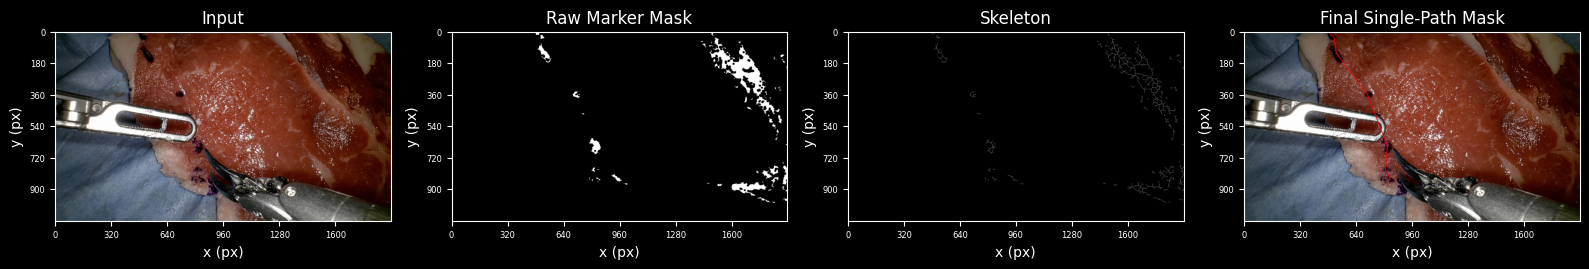

In [12]:
      # ------ Visualization ------

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

overlay = img_rgb.copy()
overlay[final_mask > 0] = [255, 0, 0]  # red overlay on extracted trajectory

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles  = ["Input", "Raw Marker Mask", "Skeleton", "Final Single-Path Mask"]
images  = [img_rgb, raw_mask, skel, overlay]
cmaps   = [None, "gray", "gray", None]

for ax, title, im, cmap in zip(axes, titles, images, cmaps):
    ax.set_title(title)
    ax.imshow(im, cmap=cmap)
    # show pixel-coordinate axes (x = col, y = row)
    h, w = im.shape[:2]
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.tick_params(labelsize=6)
    # keep only a few ticks so the plot stays readable
    x_ticks = list(range(0, w, max(1, w // 6)))
    y_ticks = list(range(0, h, max(1, h // 6)))
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

plt.tight_layout()
plt.show()


In [7]:
#test individual function
import cv2
import numpy as np
from skimage.morphology import skeletonize

def show(title, img):
    if img is None:
        print(title, "is None")
        return
    if img.dtype == bool:
        img = img.astype(np.uint8) * 255
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.imshow(title, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

def draw_points(img, pts, color=(0,255,0), r=3):
    vis = img.copy()
    for x, y in pts:
        cv2.circle(vis, (int(x), int(y)), r, color, -1)
    return vis
#1
def test_visualize_enhance_contrast(img_bgr):
    out = enhance_contrast_bgr(img_bgr)
    show("enhance_contrast_bgr", out)

#2
def test_visualize_filter_components(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

    out = filter_components(binary, CFG["min_component_area"], CFG["max_component_area_ratio"])

    show("filter input", binary)
    show("filter output", out)
#3
def test_visualize_tissue_roi(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    #roi = build_tissue_roi(lab[:,:,0], hsv[:,:,2], hsv[:,:,0])
    roi = build_tissue_roi(lab[:,:,0], hsv[:,:,2], hsv[:,:,0], hsv[:,:,1])
    show("tissue_roi", roi)
#4
def test_visualize_segment_dark_marker(img_bgr):
    mask = segment_dark_marker(img_bgr)
    show("segment_dark_marker", mask)
#5
def test_visualize_skeleton_to_graph(img_bgr):
    mask = segment_dark_marker(img_bgr)
    skel = skeletonize(mask > 0)

    G = skeleton_to_graph(skel)

    vis = np.zeros((*skel.shape, 3), dtype=np.uint8)
    for y, x in G.nodes():
        vis[y, x] = (0,255,0)

    show("skeleton nodes", vis)
    print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

def test_visualize_prune_short_branches(img_bgr):
    mask = segment_dark_marker(img_bgr)
    skel = skeletonize(mask > 0)

    G = skeleton_to_graph(skel)
    G2 = prune_short_branches(G.copy(), min_len=10)

    vis_before = np.zeros((*skel.shape,3), np.uint8)
    for y,x in G.nodes():
        vis_before[y,x]=(0,0,255)

    vis_after = np.zeros((*skel.shape,3), np.uint8)
    for y,x in G2.nodes():
        vis_after[y,x]=(0,255,0)

    show("before prune", vis_before)
    show("after prune", vis_after)

#7
def test_visualize_longest_graph_path(img_bgr):
    mask = segment_dark_marker(img_bgr)
    skel = skeletonize(mask > 0)

    path = _extract_longest_path_from_graph(skel)
    show("longest path", path)

#8
def test_visualize_component_anchors(img_bgr):
    mask = segment_dark_marker(img_bgr)
    anchors, labels = _extract_component_anchors_with_features(mask)

    pts = [a["point"] for a in anchors]
    vis = draw_points(img_bgr, pts, (0,255,0), 4)

    show("component anchors", vis)
    print("num anchors:", len(anchors))

#9
def test_visualize_principal_axis(img_bgr):
    mask = segment_dark_marker(img_bgr)
    anchors, _ = _extract_component_anchors_with_features(mask)

    pts = np.array([a["point"] for a in anchors])
    mean, u, n = _compute_principal_axis(pts)

    vis = img_bgr.copy()

    p1 = mean - 200*u
    p2 = mean + 200*u
    cv2.line(vis, tuple(p1.astype(int)), tuple(p2.astype(int)), (0,255,0), 2)

    p3 = mean - 200*n
    p4 = mean + 200*n
    cv2.line(vis, tuple(p3.astype(int)), tuple(p4.astype(int)), (255,0,0), 2)

    show("principal axis (green) + normal (blue)", vis)

#10
def test_visualize_longest_chain(img_bgr):
    mask = segment_dark_marker(img_bgr)
    anchors, _ = _extract_component_anchors_with_features(mask)

    chain = _direction_constrained_chain(anchors, max_link_dist=CFG["max_link_dist"], max_l_deg=CFG["chain_max_angle_deg"])

    vis = img_bgr.copy()

    for c in chain:
        x,y = c["point"]
        cv2.circle(vis,(int(x),int(y)),4,(0,255,0),-1)

    for a,b in zip(chain[:-1], chain[1:]):
        cv2.line(vis,
                 tuple(a["point"].astype(int)),
                 tuple(b["point"].astype(int)),
                 (0,255,255),2)

    show("longest smooth chain", vis)

#11
def test_visualize_single_path_mask(img_bgr):
    mask = segment_dark_marker(img_bgr)
    single, skel = extract_single_path_mask(mask)

    show("input mask", mask)
    show("skeleton", skel)
    show("single path", single)

## Tuning tips for dashed/dotted lines

For purple/blue marker lines (current default):
- Tighten color band if too much noise: increase `marker_s_min`, increase `marker_v_min`, narrow `marker_h_min`/`marker_h_max`
- Loosen color band if line is missed: decrease `marker_s_min` and slightly widen hue range

For black marker datasets:
- Set `use_color_marker=False` to force dark-ink mode
- Then tune `lab_l_max`, `hsv_v_max`, and `hsv_s_max`

If dashed line pieces are not connected:
- Increase `close_kernel` (e.g., 13 or 15)
- Increase `close_iters` (e.g., 2)
- Increase `max_link_dist` and `max_proj_gap` moderately

If the path makes sudden jumps:
- Decrease `max_link_dist`
- Decrease `max_proj_gap`
- Decrease `max_lateral_dev`

If branches/noisy side paths remain:
- Increase `prune_branch_length`
- Increase `min_component_area`

If the path is too thin or too thick:
- Adjust `line_thickness` and `link_thickness`

The output is always a same-size binary mask (`uint8`, values 0/255).

In [ ]:
# --- Interactive multi-group polygon labeling with zoom ---
img_bgr = cv2.imread("../left_image_selected/38/54.png")
img = enhance_contrast_bgr(img_bgr)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h = hsv[:,:,0]; s = hsv[:,:,1]; v = hsv[:,:,2]
l = lab[:,:,0]; a_ch = lab[:,:,1]; b_ch = lab[:,:,2]
roi = build_tissue_roi(l, v, h, s)

# Groups: each group has a name, color, and list of polygons
# Press 1-9 to switch active group. Default groups below â€” edit as needed.
groups = {
    1: {'name': 'ink',   'color': (0, 255, 0),   'polys': []},
    2: {'name': 'metal', 'color': (255, 0, 0),   'polys': []},
    3: {'name': 'meat',  'color': (0, 255, 255), 'polys': []},
    4: {'name': 'cloth', 'color': (255, 0, 255), 'polys': []},
}
active_group = 1
current_poly = []

img_h, img_w = img.shape[:2]
DISP_W, DISP_H = 1280, 720
state = {
    'zoom': 1.0,
    'cx': img_w // 2,
    'cy': img_h // 2,
    'dragging': False,
    'drag_start': None,
    'drag_cx': 0,
    'drag_cy': 0,
}

def get_view():
    vw = min(int(img_w / state['zoom']), img_w)
    vh = min(int(img_h / state['zoom']), img_h)
    x1 = max(0, min(state['cx'] - vw // 2, img_w - vw))
    y1 = max(0, min(state['cy'] - vh // 2, img_h - vh))
    return x1, y1, x1 + vw, y1 + vh

def disp_to_img(dx, dy):
    x1, y1, x2, y2 = get_view()
    ix = x1 + int(dx * (x2 - x1) / DISP_W)
    iy = y1 + int(dy * (y2 - y1) / DISP_H)
    return max(0, min(ix, img_w - 1)), max(0, min(iy, img_h - 1))

def redraw():
    vis = img.copy()
    # Draw all confirmed polygons with group colors
    for gid, grp in groups.items():
        for i, poly in enumerate(grp['polys']):
            cv2.polylines(vis, [poly], True, grp['color'], 2)
            pcx = int(np.mean(poly[:, 0, 0]))
            pcy = int(np.mean(poly[:, 0, 1]))
            cv2.putText(vis, f"{grp['name']}:{i}", (pcx, pcy - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, grp['color'], 1)
    # Draw current in-progress polygon in active group color
    clr = groups[active_group]['color']
    for j, pt in enumerate(current_poly):
        cv2.circle(vis, pt, 3, clr, -1)
        if j > 0:
            cv2.line(vis, current_poly[j - 1], current_poly[j], clr, 1)
    # HUD: show active group
    cv2.putText(vis, f"Active: [{active_group}] {groups[active_group]['name']}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, clr, 2)
    # Crop to view
    x1, y1, x2, y2 = get_view()
    crop = vis[y1:y2, x1:x2]
    return cv2.resize(crop, (DISP_W, DISP_H), interpolation=cv2.INTER_LINEAR)

def mouse_cb(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and not state['dragging']:
        ix, iy = disp_to_img(x, y)
        current_poly.append((ix, iy))
        cv2.imshow(win_name, redraw())
    elif event == cv2.EVENT_MOUSEWHEEL:
        ix, iy = disp_to_img(x, y)
        if flags > 0:
            state['zoom'] = min(state['zoom'] * 1.3, 20.0)
        else:
            state['zoom'] = max(state['zoom'] / 1.3, 1.0)
        state['cx'], state['cy'] = ix, iy
        cv2.imshow(win_name, redraw())
    elif event == cv2.EVENT_RBUTTONDOWN:
        state['dragging'] = True
        state['drag_start'] = (x, y)
        state['drag_cx'] = state['cx']
        state['drag_cy'] = state['cy']
    elif event == cv2.EVENT_MOUSEMOVE and state['dragging']:
        dx = x - state['drag_start'][0]
        dy = y - state['drag_start'][1]
        vw = int(img_w / state['zoom'])
        vh = int(img_h / state['zoom'])
        state['cx'] = state['drag_cx'] - int(dx * vw / DISP_W)
        state['cy'] = state['drag_cy'] - int(dy * vh / DISP_H)
        state['cx'] = max(0, min(state['cx'], img_w))
        state['cy'] = max(0, min(state['cy'], img_h))
        cv2.imshow(win_name, redraw())
    elif event == cv2.EVENT_RBUTTONUP:
        state['dragging'] = False

win_name = "Multi-Group Labeling"
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(win_name, DISP_W, DISP_H)
cv2.setMouseCallback(win_name, mouse_cb)
cv2.imshow(win_name, redraw())

print("=== CONTROLS ===")
print("  1-4          : switch active group (1=ink, 2=metal, 3=meat, 4=cloth)")
print("  Left-click   : place polygon point")
print("  ENTER/SPACE  : confirm polygon")
print("  Scroll wheel : zoom in/out")
print("  Right-drag   : pan")
print("  'c'          : cancel current polygon")
print("  'z'          : undo last polygon in active group")
print("  'r'          : reset view")
print("  'q'/ESC      : done")

while True:
    key = cv2.waitKey(0) & 0xFF
    if key == ord('q') or key == 27:
        if len(current_poly) > 0:
            print("  (Discarded unfinished polygon)")
        break
    elif key in [ord('1'), ord('2'), ord('3'), ord('4')]:
        if len(current_poly) > 0:
            print("  (Discarded unfinished polygon for previous group)")
            current_poly.clear()
        active_group = key - ord('0')
        print(f"  Switched to group [{active_group}] {groups[active_group]['name']}")
        cv2.imshow(win_name, redraw())
    elif key == 13 or key == 32:
        if len(current_poly) >= 3:
            poly = np.array(current_poly, dtype=np.int32).reshape(-1, 1, 2)
            groups[active_group]['polys'].append(poly)
            idx = len(groups[active_group]['polys']) - 1
            print(f"  Confirmed {groups[active_group]['name']} #{idx}: "
                  f"{len(current_poly)} pts, area={cv2.contourArea(poly):.0f}")
            current_poly.clear()
            cv2.imshow(win_name, redraw())
        else:
            print("  Need >= 3 points.")
    elif key == ord('c'):
        current_poly.clear()
        cv2.imshow(win_name, redraw())
        print("  Cancelled current polygon.")
    elif key == ord('z'):
        if groups[active_group]['polys']:
            groups[active_group]['polys'].pop()
            current_poly.clear()
            cv2.imshow(win_name, redraw())
            print(f"  Undid last {groups[active_group]['name']} polygon.")
    elif key == ord('r'):
        state['zoom'] = 1.0
        state['cx'] = img_w // 2
        state['cy'] = img_h // 2
        cv2.imshow(win_name, redraw())
    elif key == ord('+') or key == ord('='):
        state['zoom'] = min(state['zoom'] * 1.5, 20.0)
        cv2.imshow(win_name, redraw())
    elif key == ord('-'):
        state['zoom'] = max(state['zoom'] / 1.5, 1.0)
        cv2.imshow(win_name, redraw())

cv2.destroyAllWindows()

print(f"\n=== COLLECTED REGIONS ===")
for gid, grp in groups.items():
    print(f"  [{gid}] {grp['name']}: {len(grp['polys'])} polygons")
    for i, poly in enumerate(grp['polys']):
        print(f"      #{i}: {len(poly)} vertices, area={cv2.contourArea(poly):.0f} px")


In [ ]:
# --- Snippet 2: Multi-group analysis (per-group stats + pairwise) ---
import cv2, numpy as np

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
l, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]

channels = {'H': h, 'S': s, 'V': v, 'L': l, 'a': a, 'b': b}

# Collect pixels per group
group_pixels = {}   # name -> dict of channel arrays
for gid, gdata in groups.items():
    if not gdata['polys']:
        continue
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for poly in gdata['polys']:
        pts = np.array(poly, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
    idx = mask == 255
    if idx.sum() == 0:
        continue
    group_pixels[gdata['name']] = {ch: arr[idx] for ch, arr in channels.items()}

# --- Part 1: Per-group summary ---
print("=" * 72)
print("PER-GROUP SUMMARY")
print("=" * 72)
ch_names = ['H', 'S', 'V', 'L', 'a', 'b']
for name, pix in group_pixels.items():
    n = len(pix['H'])
    print(f"\n  {name.upper()} ({n} pixels)")
    print(f"  {'Chan':>4}   {'Mean':>7}  {'Std':>7}  {'Min':>5}  {'Max':>5}")
    print(f"  {'-'*40}")
    for ch in ch_names:
        arr = pix[ch]
        print(f"  {ch:>4}   {arr.mean():7.1f}  {arr.std():7.1f}  {int(arr.min()):5d}  {int(arr.max()):5d}")

# --- Part 2: Pairwise comparison ---
names = list(group_pixels.keys())
if len(names) >= 2:
    print("\n" + "=" * 72)
    print("PAIRWISE COMPARISON (mean_A - mean_B)")
    print("=" * 72)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            nA, nB = names[i], names[j]
            print(f"\n  {nA.upper()} vs {nB.upper()}")
            print(f"  {'Chan':>4}   {nA:>10}  {nB:>10}  {'Delta':>8}  {'Sep?':>5}")
            print(f"  {'-'*50}")
            for ch in ch_names:
                mA = group_pixels[nA][ch].mean()
                mB = group_pixels[nB][ch].mean()
                sA = group_pixels[nA][ch].std()
                sB = group_pixels[nB][ch].std()
                delta = mA - mB
                # separable if gap between means > sum of stds
                gap = abs(delta) - (sA + sB)
                sep = "YES" if gap > 0 else "no"
                print(f"  {ch:>4}   {mA:10.1f}  {mB:10.1f}  {delta:+8.1f}  {sep:>5}")


In [ ]:
# ============================================================
# ML Dark-Mode Threshold Learning v3  (run after cells 2 + 3)
# ============================================================
import cv2, numpy as np, os, glob
from scipy.optimize import differential_evolution

# ---------- CONFIG ----------
FOLDER    = r"../left_image_selected/MLFolder"
FN_RAD    = 12
BG_N      = 1500
PW, PH    = 640, 720
MAX_PX    = 50000

CUR_V_MAX = 120;  CUR_S_MIN = 190;  CUR_H_MIN = 15;  CUR_L_MAX = 70
MIN_REC   = 0.90
# -----------------------------

paths = sorted(glob.glob(os.path.join(FOLDER, "*.png")))
print(f"Found {len(paths)} images")
all_ink, all_noink = [], []

# ---- viewport ----
vp = dict(z=1.0,cx=0,cy=0,drag=False,ds=None,dcx=0,dcy=0,iw=1,ih=1,fn=False)
def vp_reset(w,h): vp.update(z=1.0,cx=w//2,cy=h//2,drag=False,iw=w,ih=h,fn=False)
def vp_rect():
    w,h=vp['iw'],vp['ih']; vw,vh=min(int(w/vp['z']),w),min(int(h/vp['z']),h)
    x1=max(0,min(vp['cx']-vw//2,w-vw)); y1=max(0,min(vp['cy']-vh//2,h-vh))
    return x1,y1,x1+vw,y1+vh
def d2i(dx,dy):
    px=dx%PW; x1,y1,x2,y2=vp_rect()
    return (max(0,min(x1+int(px*(x2-x1)/PW),vp['iw']-1)),
            max(0,min(y1+int(dy*(y2-y1)/PH),vp['ih']-1)))

# ================ PER-IMAGE LABELING ================
for img_idx, path in enumerate(paths):
    raw = cv2.imread(path, cv2.IMREAD_COLOR)
    if raw is None: print(f"  Skip: {path}"); continue
    fname = os.path.basename(path)
    img   = enhance_contrast_bgr(raw)
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab   = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    hc,sc,vc,lc = hsv[:,:,0],hsv[:,:,1],hsv[:,:,2],lab[:,:,0]
    ih_,iw_ = img.shape[:2]
    roi   = build_tissue_roi(lc,vc,hc,sc)

    # ---- raw mask with morphology (same pipeline as segment_dark_marker) ----
    md = ((vc<=CUR_V_MAX)&(sc>=CUR_S_MIN)&(hc>=CUR_H_MIN)&(lc<=CUR_L_MAX))
    md = cv2.bitwise_and((md.astype(np.uint8)*255), roi)
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(CFG["open_kernel"],CFG["open_kernel"]))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(CFG["close_kernel"],CFG["close_kernel"]))
    md = cv2.morphologyEx(md, cv2.MORPH_OPEN, k_open)
    md = cv2.morphologyEx(md, cv2.MORPH_CLOSE, k_close, iterations=CFG["close_iters"])
    md = filter_components(md, CFG["min_component_area"], CFG["max_component_area_ratio"])

    nlab,labels,stats,_ = cv2.connectedComponentsWithStats(md,8)

    # ---- PRE-COMPUTE overlay (once, not every redraw) ----
    overlay = img.copy()
    blob_mask = md > 0
    # Vibrant orange (BGR: 0,165,255)
    overlay[blob_mask] = (overlay[blob_mask].astype(np.int16)*4//10
                          + np.array([0,165,255],dtype=np.int16)*6//10).clip(0,255).astype(np.uint8)

    tp_set=set(); fn_pts=[]; vp_reset(iw_,ih_)

    def draw():
        x1,y1,x2,y2 = vp_rect()
        left = cv2.resize(img[y1:y2,x1:x2],(PW,PH),interpolation=cv2.INTER_LINEAR)
        # Start from pre-computed overlay, just draw markers on top
        vis = overlay.copy()
        # Green fill for confirmed TP blobs
        for lid in tp_set:
            vis[labels==lid] = (img[labels==lid].astype(np.int16)*3//10
                                + np.array([0,220,0],dtype=np.int16)*7//10).clip(0,255).astype(np.uint8)
        for fx,fy in fn_pts:
            cv2.circle(vis,(fx,fy),FN_RAD,(0,255,255),2)
            cv2.drawMarker(vis,(fx,fy),(0,255,255),cv2.MARKER_CROSS,10,2)
        right = cv2.resize(vis[y1:y2,x1:x2],(PW,PH),interpolation=cv2.INTER_LINEAR)
        out = np.hstack([left,right])
        tag="FN" if vp['fn'] else "TP"
        cv2.putText(out,f"[{img_idx+1}/{len(paths)}] {fname}  TP:{len(tp_set)} FN:{len(fn_pts)} det:{nlab-1}  Mode:{tag}",
                    (10,30),cv2.FONT_HERSHEY_SIMPLEX,0.65,(255,255,255),2)
        cv2.putText(out,"f=toggle a=allTP n=next s=skip q=quit z=undoFN r=reset",
                    (10,58),cv2.FONT_HERSHEY_SIMPLEX,0.48,(200,200,200),1)
        cv2.putText(out,"ORIGINAL",(PW//2-50,PH-12),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,0),1)
        cv2.putText(out,"DETECTION",(PW+PW//2-55,PH-12),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),1)
        return out

    def on_mouse(ev,x,y,flags,_):
        if ev==cv2.EVENT_LBUTTONDOWN and not vp['drag']:
            ix,iy=d2i(x,y)
            if vp['fn']:
                fn_pts.append((ix,iy)); print(f"    FN at ({ix},{iy})")
            else:
                lid=labels[iy,ix]
                if lid>0:
                    if lid in tp_set: tp_set.discard(lid); print(f"    Un-marked #{lid}")
                    else: tp_set.add(lid); print(f"    TP #{lid} area={stats[lid,cv2.CC_STAT_AREA]}")
            cv2.imshow(W,draw())
        elif ev==cv2.EVENT_MOUSEWHEEL:
            ix,iy=d2i(x,y)
            vp['z']=min(vp['z']*1.3,20) if flags>0 else max(vp['z']/1.3,1)
            vp['cx'],vp['cy']=ix,iy; cv2.imshow(W,draw())
        elif ev==cv2.EVENT_RBUTTONDOWN:
            vp.update(drag=True,ds=(x,y),dcx=vp['cx'],dcy=vp['cy'])
        elif ev==cv2.EVENT_MOUSEMOVE and vp['drag']:
            dx_,dy_=x-vp['ds'][0],y-vp['ds'][1]
            vp['cx']=max(0,min(vp['dcx']-int(dx_*iw_/vp['z']/PW),iw_))
            vp['cy']=max(0,min(vp['dcy']-int(dy_*ih_/vp['z']/PH),ih_))
            cv2.imshow(W,draw())
        elif ev==cv2.EVENT_RBUTTONUP: vp['drag']=False

    W="ML Labeling"
    cv2.namedWindow(W,cv2.WINDOW_NORMAL); cv2.resizeWindow(W,2*PW,PH)
    cv2.setMouseCallback(W,on_mouse); cv2.imshow(W,draw())

    action='next'
    while True:
        k=cv2.waitKey(0)&0xFF
        if   k==ord('q') or k==27: action='quit'; break
        elif k==ord('n') or k==13: break
        elif k==ord('s'): action='skip'; break
        elif k==ord('f'):
            vp['fn']=not vp['fn']; print(f"    Mode->{'FN' if vp['fn'] else 'TP'}"); cv2.imshow(W,draw())
        elif k==ord('a'):
            tp_set=set(range(1,nlab)); print(f"    All {nlab-1}->TP"); cv2.imshow(W,draw())
        elif k==ord('z') and fn_pts: fn_pts.pop(); cv2.imshow(W,draw())
        elif k==ord('r'): vp_reset(iw_,ih_); cv2.imshow(W,draw())
    cv2.destroyAllWindows()

    if action=='skip': print(f"  Skipped {fname}"); continue

    # ---- collect raw pixels (pre-morphology channels) for learning ----
    feat=np.stack([hc,sc,vc,lc],axis=-1)
    for lid in tp_set:            all_ink.append(feat[labels==lid])
    yy,xx=np.ogrid[:ih_,:iw_]
    for fx,fy in fn_pts:
        circ=((xx-fx)**2+(yy-fy)**2<=FN_RAD**2)&(roi>0)
        if circ.any(): all_ink.append(feat[circ])
    for lid in range(1,nlab):
        if lid not in tp_set: all_noink.append(feat[labels==lid])
    bg_mask=(roi>0)&(md==0); bg_idx=np.where(bg_mask.ravel())[0]
    if len(bg_idx)>BG_N: bg_idx=np.random.choice(bg_idx,BG_N,replace=False)
    if len(bg_idx)>0: all_noink.append(feat.reshape(-1,4)[bg_idx])

    print(f"  [{img_idx+1}/{len(paths)}] {fname}: TP={len(tp_set)} FN={len(fn_pts)} FP={nlab-1-len(tp_set)}")
    if action=='quit': print("Stopped."); break

# ================ AGGREGATE ================
if not all_ink: raise RuntimeError("No ink pixels collected!")
ink   = np.concatenate(all_ink).astype(np.float64)
noink = np.concatenate(all_noink).astype(np.float64) if all_noink else np.zeros((0,4),np.float64)
print(f"\n{'='*60}")
print(f"COLLECTED: {len(ink)} ink px,  {len(noink)} non-ink px")

rng=np.random.default_rng(42)
ink_opt   = ink[rng.choice(len(ink),min(MAX_PX,len(ink)),replace=False)]
noink_opt = noink[rng.choice(len(noink),min(MAX_PX,len(noink)),replace=False)] if len(noink)>0 else noink

# ================ DIFFERENTIAL EVOLUTION ================
def cost(params):
    h_cen,h_hw = params[0],params[1]
    s_lo,s_hi = min(params[2],params[3]),max(params[2],params[3])
    v_lo,v_hi = min(params[4],params[5]),max(params[4],params[5])
    l_lo,l_hi = min(params[6],params[7]),max(params[6],params[7])
    hd=np.minimum(np.abs(ink_opt[:,0]-h_cen),180-np.abs(ink_opt[:,0]-h_cen))
    im=(hd<=h_hw)&(ink_opt[:,1]>=s_lo)&(ink_opt[:,1]<=s_hi)& \
       (ink_opt[:,2]>=v_lo)&(ink_opt[:,2]<=v_hi)&(ink_opt[:,3]>=l_lo)&(ink_opt[:,3]<=l_hi)
    tp=im.sum(); rec=tp/max(1,len(ink_opt))
    if rec<MIN_REC: return 2.0+(MIN_REC-rec)*10
    if len(noink_opt)>0:
        hdn=np.minimum(np.abs(noink_opt[:,0]-h_cen),180-np.abs(noink_opt[:,0]-h_cen))
        nm=(hdn<=h_hw)&(noink_opt[:,1]>=s_lo)&(noink_opt[:,1]<=s_hi)& \
           (noink_opt[:,2]>=v_lo)&(noink_opt[:,2]<=v_hi)&(noink_opt[:,3]>=l_lo)&(noink_opt[:,3]<=l_hi)
        fp=nm.sum()
    else: fp=0
    prec=tp/max(1,tp+fp); f1=2*prec*rec/max(1e-6,prec+rec)
    return -f1

de_bounds=[(0,179),(0,90),(0,255),(0,255),(0,255),(0,255),(0,255),(0,255)]
print(f"\nRunning differential evolution (8 params)...")
result=differential_evolution(cost,de_bounds,seed=42,maxiter=500,popsize=20,tol=1e-8,disp=True)
print(f"Converged: {result.nit} generations, {result.nfev} evaluations")

h_cen,h_hw=int(round(result.x[0])),int(round(result.x[1]))
s_lo,s_hi=int(round(min(result.x[2],result.x[3]))),int(round(max(result.x[2],result.x[3])))
v_lo,v_hi=int(round(min(result.x[4],result.x[5]))),int(round(max(result.x[4],result.x[5])))
l_lo,l_hi=int(round(min(result.x[6],result.x[7]))),int(round(max(result.x[6],result.x[7])))
h_lo=(h_cen-h_hw)%180; h_hi=(h_cen+h_hw)%180; h_wraps=h_lo>h_hi

# Evaluate on full data
hd=np.minimum(np.abs(ink[:,0]-h_cen),180-np.abs(ink[:,0]-h_cen))
im_f=(hd<=h_hw)&(ink[:,1]>=s_lo)&(ink[:,1]<=s_hi)& \
     (ink[:,2]>=v_lo)&(ink[:,2]<=v_hi)&(ink[:,3]>=l_lo)&(ink[:,3]<=l_hi)
tp=im_f.sum(); fn=len(ink)-tp
if len(noink)>0:
    hdn=np.minimum(np.abs(noink[:,0]-h_cen),180-np.abs(noink[:,0]-h_cen))
    nm_f=(hdn<=h_hw)&(noink[:,1]>=s_lo)&(noink[:,1]<=s_hi)& \
         (noink[:,2]>=v_lo)&(noink[:,2]<=v_hi)&(noink[:,3]>=l_lo)&(noink[:,3]<=l_hi)
    fp=nm_f.sum()
else: fp=0
prec=tp/max(1,tp+fp); rec=tp/max(1,tp+fn); f1=2*prec*rec/max(1e-6,prec+rec)

# ================ OUTPUT ================
print(f"\n{'='*60}")
print("LEARNED DARK MODE PARAMETERS")
print(f"{'='*60}")
print(f"  Hue center={h_cen} halfwidth={h_hw} -> [{h_lo},{h_hi}]{' WRAP' if h_wraps else ''}")
parts=[]
if h_wraps:
    print(f"  H: (h >= {h_lo}) | (h <= {h_hi})"); parts.append(f"((h >= {h_lo}) | (h <= {h_hi}))")
else:
    sub=[]
    if h_lo>0:   sub.append(f"(h >= {h_lo})"); print(f"  H lo: {h_lo}")
    if h_hi<179: sub.append(f"(h <= {h_hi})"); print(f"  H hi: {h_hi}")
    if sub: parts.append(" & ".join(sub))
for cn,lo,hi,mx in [('S',s_lo,s_hi,255),('V',v_lo,v_hi,255),('L',l_lo,l_hi,255)]:
    c=cn.lower(); sub=[]
    if lo>0:  sub.append(f"({c} >= {lo})"); print(f"  {cn} lo: {lo}")
    if hi<mx: sub.append(f"({c} <= {hi})"); print(f"  {cn} hi: {hi}")
    if sub: parts.append(" & ".join(sub))
    else: print(f"  {cn}: no constraint")
print(f"\n  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(f"  TP={tp}  FP={fp}  FN={fn}")
print(f"\nPaste into segment_dark_marker mask_dark:")
print(f"    mask_dark = ({' & '.join(parts)})")
